# Анализ туризма и рынка турпакетов в регионах России


<table style="border:2px solid #8e44ad; border-radius:8px; background-color:#f8f1ff; width:100%;">
  <tr>
    <td style="padding:12px 16px;">

<b>Инсайты за 30 секунд</b>

- Средняя стоимость турпакетов в 2023 году заметно выше 800 млн руб.
- Рост внутреннего туризма в 2023 к 2022 статистически не подтверждён.
- Рынок сконцентрирован в нескольких регионах‑лидерах (Москва, Санкт‑Петербург).
    </td>
  </tr>
</table>



##1. Введение

---



В рамках кейса десятого спринта курса «Аналитик данных в продукте» я анализирую данные агрегатора отелей о туристической активности в регионах России за 2018–2023 годы.

**Цель исследования** — изучить структуру размещения туристов и продажи турпакетов, выявить самые ёмкие и перспективные регионы, а также проверить гипотезы о динамике стоимости и популярности турпродуктов.

В работе используются четыре набора данных: статистика по средствам размещения, численности размещённых гостей, количеству реализованных турпакетов и их стоимости по субъектам Российской Федерации.

##2. Описание данных

---



В проекте используются четыре набора данных по субъектам Российской Федерации.

**1. hotel.csv** — статистика по средствам размещения за 2018–2023 годы:  
- «Субъект» — наименование субъекта РФ.  
- «Число гостиниц».  
- «Число мест в гостиницах».  
- «Число хостелов».  
- «Число мест в хостелах».  
- «Число санаторно-курортных организаций».  
- «Число мест в санаторно-курортных организациях».  

**2. count_person_hotel.csv** — число людей, размещённых в гостиницах в 2023 году:  
- «Субъект».  
- «Численность лиц, размещённых в гостиницах в 2023 году».  
- «Численность граждан России, размещённых в гостиницах в 2023 году».  
- «Численность иностранных граждан, размещённых в гостиницах в 2023 году».  

**3. tour_firm.csv** — число оформленных турпакетов в 2018–2023 годы:  
- «Субъект».  
- «Общее число турпакетов, реализованных населению».  
- «Общее число турпакетов, реализованных гражданам России по территории России».  
- «Общее число турпакетов, реализованных гражданам России по другим странам».  
- «Общее число турпакетов, реализованных гражданам других стран по территории России».  

**4. tour_cost_2023.csv** — стоимость реализованных турпакетов в 2023 году (млн руб.):  
- «Субъект».  
- «Стоимость реализованных турпакетов в 2023 году».  
- «Стоимость турпакетов, реализованных гражданам России по территории России в 2023 году».  
- «Стоимость турпакетов, реализованных гражданам России по другим странам в 2023 году».  


## Содержание

1. [Введение](#введение)  
2. [Описание данных](#описание-данных)  
3. [Подготовка данных](#подготовка-данных)  
   3.1. [Загрузка датасетов](#загрузка-датасетов)  
   3.2. [Проверка типов данных](#проверка-типов-данных)  
   3.3. [Анализ пропусков](#анализ-пропусков-и-аномалий)  
   3.4. [Проверка числовых значений на аномалии](#проверка-числовых-значений-на-аномалии)  
4. [Исследовательский анализ данных (EDA)](#исследовательский-анализ-данных-eda)  
   4.1. [Распределение средств размещения](#распределение-средств-размещения)  
   4.2. [Топ-10 регионов по стоимости турпакетов в 2023 году](#топ-10-регионов-по-стоимости-турпакетов-в-2023-году)  
   4.3. [Динамика среднего количества турпакетов по категориям](#динамика-среднего-количества-турпакетов-по-категориям)  
5. [Проверка гипотез](#проверка-гипотез)  
   5.1. [Средняя стоимость турпакетов в 2023 году](#средняя-стоимость-турпакетов-в-2023-году)  
   5.2. [Изменение внутреннего туризма](#изменение-внутреннего-туризма)  
6. [Выводы](#выводы)  
   6.1. [Общий обзор проделанной работы](#общий-обзор-проделанной-работы)  
   6.2. [Ключевые выводы](#ключевые-выводы)  
   6.3. [Рекомендации для заказчика](#рекомендации-для-заказчика)


##3. Подготовка данных

---




###3.1 Загрузка датасетов

В этом подразделе данные загружаются в окружение, проверяется успешность чтения файлов и базовая структура таблиц.

> Подключим библиотеки для анализа данных и визуализаций.




In [ ]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import missingno as msno
    import plotly.express as px
except ImportError as e:
    print(f'Не удалось импортировать библиотеку: {e}')

plt.rcParams['axes.grid'] = False



> Загрузим данные из файлов в датафреймы.





In [ ]:
hotel = pd.read_csv('hotel.csv', sep=';')
count_person = pd.read_csv('count_person_hotel.csv', sep=';')
tour_firm = pd.read_csv('tour_firm.csv', sep=';')
tour_cost = pd.read_csv('tour_cost_2023.csv', sep=';')



> Проверим, что данные загружены корректно, и посмотрим на первые строки таблицы `hotel`.



In [ ]:
hotel.head()


,Субъект,"Число гостиниц, 2018","Число гостиниц, 2019","Число гостиниц, 2020","Число гостиниц, 2021","Число гостиниц, 2022","Число гостиниц, 2023","Число мест в гостиницах, 2018","Число мест в гостиницах, 2019","Число мест в гостиницах, 2020",...,"Число санаторно-курортных организаций, 2020","Число санаторно-курортных организаций, 2021","Число санаторно-курортных организаций, 2022","Число санаторно-курортных организаций, 2023","Число мест в санаторно-курортных организациях, 2018","Число мест в санаторно-курортных организациях, 2019","Число мест в санаторно-курортных организациях, 2020","Число мест в санаторно-курортных организациях, 2021","Число мест в санаторно-курортных организациях, 2022","Число мест в санаторно-курортных организациях, 2023"
0,Белгородская область,97,101,103,100,101,99,4753,5144,5390,...,11,11,11,11,1969,1938,1969,1969,2212,1999
1,Брянская область,74,78,86,92,91,93,3436,3507,3782,...,14,14,14,13,2953,2829,2430,2837,2672,2937
2,Владимирская область,100,100,114,119,121,125,7679,8059,8815,...,6,8,9,8,1220,1324,1205,1530,1542,1328
3,Воронежская область,141,147,151,163,170,179,9605,10419,10040,...,15,15,14,14,3241,3302,3320,3320,3243,3337
4,Ивановская область,48,52,55,74,64,59,2774,2998,3009,...,14,17,15,15,4347,4341,4485,4616,4396,4293


In [ ]:
def print_columns(df, name):
    """Выводит название датафрейма и список его столбцов."""
    print(f'=== {name} ===')
    for col in df.columns:
        print(col)
    print('-' * 80)


print_columns(hotel, 'hotel')
print_columns(count_person, 'count_person')
print_columns(tour_firm, 'tour_firm')
print_columns(tour_cost, 'tour_cost')

=== hotel ===
Субъект
Число гостиниц, 2018
Число гостиниц, 2019
Число гостиниц, 2020
Число гостиниц, 2021
Число гостиниц, 2022
Число гостиниц, 2023
Число мест в гостиницах, 2018
Число мест в гостиницах, 2019
Число мест в гостиницах, 2020
Число мест в гостиницах, 2021
Число мест в гостиницах, 2022
Число мест в гостиницах, 2023
Число хостелов, 2018
Число хостелов, 2019
Число хостелов, 2020
Число хостелов, 2021
Число хостелов, 2022
Число хостелов, 2023
Число мест в хостелах, 2018
Число мест в хостелах, 2019
Число мест в хостелах, 2020
Число мест в хостелах, 2021
Число мест в хостелах, 2022
Число мест в хостелах, 2023
Число санаторно-курортных организаций, 2018
Число санаторно-курортных организаций, 2019
Число санаторно-курортных организаций, 2020
Число санаторно-курортных организаций, 2021
Число санаторно-курортных организаций, 2022
Число санаторно-курортных организаций, 2023
Число мест в санаторно-курортных организациях, 2018
Число мест в санаторно-курортных организациях, 2019
Число мест

In [ ]:
hotel = hotel.rename(columns={
    'Субъект': 'region',
    'Число гостиниц, 2018': 'hotels_2018',
    'Число гостиниц, 2019': 'hotels_2019',
    'Число гостиниц, 2020': 'hotels_2020',
    'Число гостиниц, 2021': 'hotels_2021',
    'Число гостиниц, 2022': 'hotels_2022',
    'Число гостиниц, 2023': 'hotels_2023',
    'Число мест в гостиницах, 2018': 'hotel_beds_2018',
    'Число мест в гостиницах, 2019': 'hotel_beds_2019',
    'Число мест в гостиницах, 2020': 'hotel_beds_2020',
    'Число мест в гостиницах, 2021': 'hotel_beds_2021',
    'Число мест в гостиницах, 2022': 'hotel_beds_2022',
    'Число мест в гостиницах, 2023': 'hotel_beds_2023',
    'Число хостелов, 2018': 'hostels_2018',
    'Число хостелов, 2019': 'hostels_2019',
    'Число хостелов, 2020': 'hostels_2020',
    'Число хостелов, 2021': 'hostels_2021',
    'Число хостелов, 2022': 'hostels_2022',
    'Число хостелов, 2023': 'hostels_2023',
    'Число мест в хостелах, 2018': 'hostel_beds_2018',
    'Число мест в хостелах, 2019': 'hostel_beds_2019',
    'Число мест в хостелах, 2020': 'hostel_beds_2020',
    'Число мест в хостелах, 2021': 'hostel_beds_2021',
    'Число мест в хостелах, 2022': 'hostel_beds_2022',
    'Число мест в хостелах, 2023': 'hostel_beds_2023',
    'Число санаторно-курортных организаций, 2018': 'sanatoriums_2018',
    'Число санаторно-курортных организаций, 2019': 'sanatoriums_2019',
    'Число санаторно-курортных организаций, 2020': 'sanatoriums_2020',
    'Число санаторно-курортных организаций, 2021': 'sanatoriums_2021',
    'Число санаторно-курортных организаций, 2022': 'sanatoriums_2022',
    'Число санаторно-курортных организаций, 2023': 'sanatoriums_2023',
    'Число мест в санаторно-курортных организациях, 2018': 'sanatorium_beds_2018',
    'Число мест в санаторно-курортных организациях, 2019': 'sanatorium_beds_2019',
    'Число мест в санаторно-курортных организациях, 2020': 'sanatorium_beds_2020',
    'Число мест в санаторно-курортных организациях, 2021': 'sanatorium_beds_2021',
    'Число мест в санаторно-курортных организациях, 2022': 'sanatorium_beds_2022',
    'Число мест в санаторно-курортных организациях, 2023': 'sanatorium_beds_2023',
})

In [ ]:
count_person = count_person.rename(columns={
    'Субъект': 'region',
    'Численность лиц, размещенных в гостиницах в 2023 году': 'guests_total_2023',
    'Численность граждан России, размещенных в гостиницах в 2023 году': 'guests_russia_2023',
    'Численность иностранных граждан, размещенных в гостиницах в 2023 году': 'guests_foreign_2023',
})

In [ ]:
tour_firm = tour_firm.rename(columns={
    'Субъект': 'region',
    'Общее число турпакетов, реализованных населению, 2018': 'packages_total_2018',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2018': 'packages_rus_domestic_2018',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2018': 'packages_rus_outbound_2018',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2018': 'packages_foreign_inbound_2018',
    'Общее число турпакетов, реализованных населению, 2019': 'packages_total_2019',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2019': 'packages_rus_domestic_2019',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2019': 'packages_rus_outbound_2019',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2019': 'packages_foreign_inbound_2019',
    'Общее число турпакетов, реализованных населению, 2020': 'packages_total_2020',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2020': 'packages_rus_domestic_2020',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2020': 'packages_rus_outbound_2020',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2020': 'packages_foreign_inbound_2020',
    'Общее число турпакетов, реализованных населению, 2021': 'packages_total_2021',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2021': 'packages_rus_domestic_2021',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2021': 'packages_rus_outbound_2021',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2021': 'packages_foreign_inbound_2021',
    'Общее число турпакетов, реализованных населению, 2022': 'packages_total_2022',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2022': 'packages_rus_domestic_2022',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2022': 'packages_rus_outbound_2022',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2022': 'packages_foreign_inbound_2022',
    'Общее число турпакетов, реализованных населению, 2023': 'packages_total_2023',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2023': 'packages_rus_domestic_2023',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2023': 'packages_rus_outbound_2023',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2023': 'packages_foreign_inbound_2023',
})


In [ ]:
tour_cost = tour_cost.rename(columns={
    'Субъект': 'region',
    'Стоимость реализованных турпакетов в 2023 году, млн руб.': 'cost_total_2023',
    'Стоимость турпакетов  реализованных гражданам России по территории России в 2023 году, млн руб.': 'cost_rus_domestic_2023',
    'Стоимость турпакетов  реализованных гражданам России по другим странам в 2023 году, млн руб.': 'cost_rus_outbound_2023',
})

In [ ]:
print_columns(hotel, 'hotel')
print_columns(count_person, 'count_person')
print_columns(tour_firm, 'tour_firm')
print_columns(tour_cost, 'tour_cost')

=== hotel ===
region
hotels_2018
hotels_2019
hotels_2020
hotels_2021
hotels_2022
hotels_2023
hotel_beds_2018
hotel_beds_2019
hotel_beds_2020
hotel_beds_2021
hotel_beds_2022
hotel_beds_2023
hostels_2018
hostels_2019
hostels_2020
hostels_2021
hostels_2022
hostels_2023
hostel_beds_2018
hostel_beds_2019
hostel_beds_2020
hostel_beds_2021
hostel_beds_2022
hostel_beds_2023
sanatoriums_2018
sanatoriums_2019
sanatoriums_2020
sanatoriums_2021
sanatoriums_2022
sanatoriums_2023
sanatorium_beds_2018
sanatorium_beds_2019
sanatorium_beds_2020
sanatorium_beds_2021
sanatorium_beds_2022
sanatorium_beds_2023
--------------------------------------------------------------------------------
=== count_person ===
region
guests_total_2023
guests_russia_2023
guests_foreign_2023
--------------------------------------------------------------------------------
=== tour_firm ===
region
packages_total_2018
packages_rus_domestic_2018
packages_rus_outbound_2018
packages_foreign_inbound_2018
packages_total_2019
package

Переименовал столбцы во всех таблицах в единый формат: латиница, snake_case, явные указания года и типа показателя (например, `hotels_2018`, `packages_rus_domestic_2023`, `cost_total_2023`). Это упростит дальнейший анализ и снизит риск ошибок при обращении к колонкам.

###3.2 Проверка типов данных

Здесь анализируются типы столбцов, выявляются несоответствия (например, числа, считанные как строки), и формулируются решения по приведению типов к корректным.




> Оценим структуру каждой таблицы: число строк и столбцов, типы данных и наличие пропусков на уровне общей информации.




In [ ]:
hotel.info()
print('-' * 80)
count_person.info()
print('-' * 80)
tour_firm.info()
print('-' * 80)
tour_cost.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   region                81 non-null     object
 1   hotels_2018           81 non-null     int64 
 2   hotels_2019           81 non-null     int64 
 3   hotels_2020           81 non-null     int64 
 4   hotels_2021           81 non-null     int64 
 5   hotels_2022           81 non-null     int64 
 6   hotels_2023           81 non-null     int64 
 7   hotel_beds_2018       81 non-null     int64 
 8   hotel_beds_2019       81 non-null     int64 
 9   hotel_beds_2020       81 non-null     int64 
 10  hotel_beds_2021       81 non-null     int64 
 11  hotel_beds_2022       81 non-null     int64 
 12  hotel_beds_2023       81 non-null     int64 
 13  hostels_2018          81 non-null     int64 
 14  hostels_2019          81 non-null     int64 
 15  hostels_2020          81 non-null     int6

In [ ]:
def optimize_int_columns(df, int_cols):
    """
    Оптимизирует целочисленные столбцы в датафрейме: подбирает минимальный подходящий
    тип (int8/int16/int32/int64) по диапазону значений и возвращает объём памяти
    до и после преобразования в байтах.
    """
    before = df[int_cols].memory_usage(deep=True).sum()
    max_vals = df[int_cols].max()
    min_vals = df[int_cols].min()

    for col in int_cols:
        cmin, cmax = min_vals[col], max_vals[col]
        if cmin >= 0:
            if cmax < np.iinfo(np.int8).max:
                df[col] = df[col].astype('int8')
            elif cmax < np.iinfo(np.int16).max:
                df[col] = df[col].astype('int16')
            elif cmax < np.iinfo(np.int32).max:
                df[col] = df[col].astype('int32')
            else:
                df[col] = df[col].astype('int64')
        else:
            if np.iinfo(np.int8).min < cmin < np.iinfo(np.int8).max:
                df[col] = df[col].astype('int8')
            elif np.iinfo(np.int16).min < cmin < np.iinfo(np.int16).max:
                df[col] = df[col].astype('int16')
            elif np.iinfo(np.int32).min < cmin < np.int32.max:
                df[col] = df[col].astype('int32')
            else:
                df[col] = df[col].astype('int64')

    after = df[int_cols].memory_usage(deep=True).sum()
    return before, after

In [ ]:
# 1. hostel_beds и sanatorium_beds -> numeric
beds_cols = [c for c in hotel.columns if 'beds' in c]
hotel[beds_cols] = hotel[beds_cols].apply(pd.to_numeric, errors='coerce')

# 2. делим числовые колонки на без NaN и с NaN
hotel_num_cols = hotel.columns.drop('region')

no_nan_cols = [c for c in hotel_num_cols if hotel[c].isna().sum() == 0]
nan_cols = [c for c in hotel_num_cols if hotel[c].isna().sum() > 0]

print('Без NaN:', no_nan_cols)
print('С NaN:', nan_cols)

# 3. оптимизируем только колонки без NaN
before_hotel, after_hotel = optimize_int_columns(hotel, no_nan_cols)
print(f'hotel (колонки без NaN): было {before_hotel/1024:.2f} КБ, стало {after_hotel/1024:.2f} КБ')


Без NaN: ['hotels_2018', 'hotels_2019', 'hotels_2020', 'hotels_2021', 'hotels_2022', 'hotels_2023', 'hotel_beds_2018', 'hotel_beds_2019', 'hotel_beds_2020', 'hotel_beds_2021', 'hotel_beds_2022', 'hotel_beds_2023', 'hostels_2018', 'hostels_2019', 'hostels_2020', 'hostels_2021', 'hostels_2022', 'hostels_2023', 'sanatoriums_2018', 'sanatoriums_2019', 'sanatoriums_2020', 'sanatoriums_2021', 'sanatoriums_2022', 'sanatoriums_2023']
С NaN: ['hostel_beds_2018', 'hostel_beds_2019', 'hostel_beds_2020', 'hostel_beds_2021', 'hostel_beds_2022', 'hostel_beds_2023', 'sanatorium_beds_2018', 'sanatorium_beds_2019', 'sanatorium_beds_2020', 'sanatorium_beds_2021', 'sanatorium_beds_2022', 'sanatorium_beds_2023']
hotel (колонки без NaN): было 15.32 КБ, стало 4.88 КБ


In [ ]:
cp_num_cols = ['guests_total_2023', 'guests_russia_2023', 'guests_foreign_2023']
before_cp, after_cp = optimize_int_columns(count_person, cp_num_cols)
print(f'count_person: было {before_cp/1024:.2f} КБ, стало {after_cp/1024:.2f} КБ')

count_person: было 2.05 КБ, стало 1.09 КБ


In [ ]:
# 1. Переводим все числовые колонки в numeric
tf_num_cols = [c for c in tour_firm.columns if c != 'region']
tour_firm[tf_num_cols] = tour_firm[tf_num_cols].apply(pd.to_numeric, errors='coerce')

# 2. Делим на колонки без NaN и с NaN
tf_no_nan = [c for c in tf_num_cols if tour_firm[c].isna().sum() == 0]
tf_with_nan = [c for c in tf_num_cols if tour_firm[c].isna().sum() > 0]

print('tour_firm без NaN:', tf_no_nan)
print('tour_firm с NaN:', tf_with_nan)

# 3. Ужимаем только без NaN, с NaN оставляем как float
before_tf, after_tf = optimize_int_columns(tour_firm, tf_no_nan)
print(f'tour_firm (без NaN): было {before_tf/1024:.2f} КБ, стало {after_tf/1024:.2f} КБ')


tour_firm без NaN: []
tour_firm с NaN: ['packages_total_2018', 'packages_rus_domestic_2018', 'packages_rus_outbound_2018', 'packages_foreign_inbound_2018', 'packages_total_2019', 'packages_rus_domestic_2019', 'packages_rus_outbound_2019', 'packages_foreign_inbound_2019', 'packages_total_2020', 'packages_rus_domestic_2020', 'packages_rus_outbound_2020', 'packages_foreign_inbound_2020', 'packages_total_2021', 'packages_rus_domestic_2021', 'packages_rus_outbound_2021', 'packages_foreign_inbound_2021', 'packages_total_2022', 'packages_rus_domestic_2022', 'packages_rus_outbound_2022', 'packages_foreign_inbound_2022', 'packages_total_2023', 'packages_rus_domestic_2023', 'packages_rus_outbound_2023', 'packages_foreign_inbound_2023']
tour_firm (без NaN): было 0.13 КБ, стало 0.13 КБ


In [ ]:
# 1. Переводим к numeric
tc_num_cols = ['cost_total_2023', 'cost_rus_domestic_2023', 'cost_rus_outbound_2023']
tour_cost[tc_num_cols] = tour_cost[tc_num_cols].apply(pd.to_numeric, errors='coerce')

# 2. Разделяем по NaN
tc_no_nan = [c for c in tc_num_cols if tour_cost[c].isna().sum() == 0]
tc_with_nan = [c for c in tc_num_cols if tour_cost[c].isna().sum() > 0]

print('tour_cost без NaN:', tc_no_nan)
print('tour_cost с NaN:', tc_with_nan)

# 3. Ужимаем только без NaN
before_tc, after_tc = optimize_int_columns(tour_cost, tc_no_nan)
print(f'tour_cost (без NaN): было {before_tc/1024:.2f} КБ, стало {after_tc/1024:.2f} КБ')


tour_cost без NaN: []
tour_cost с NaN: ['cost_total_2023', 'cost_rus_domestic_2023', 'cost_rus_outbound_2023']
tour_cost (без NaN): было 0.13 КБ, стало 0.13 КБ


Во всех таблицах проверил структуру: число строк и столбцов, типы данных и наличие пропусков.

- В `hotel` и `count_person` идентификатор региона хранится как object, количественные показатели — в целочисленном формате без пропусков, что корректно для дальнейшего анализа.
- В `hotel` столбцы с количеством мест в хостелах и санаториях изначально были object, я привёл их к числовому типу и оптимизировал разрядность для колонок без пропусков, сократив объём памяти с 7.72 КБ до 4.88 КБ; в `count_person` объём уменьшился с 2.05 КБ до 1.09 КБ.
- В `tour_firm` и `tour_cost` числовые признаки по турпакетам и их стоимости также приведены к numeric, но из‑за пропусков оставлены в формате float64, поэтому дополнительно ужать их не удалось (около 0.13 КБ до и после оптимизации).


###3.3 Анализ пропусков

В этом подразделе оценивается наличие пропусков и аномальных значений в числовых и категориальных признаках, описываются возможные причины и подходы к обработке.




> Построим сводку по количеству пропусков в каждом столбце для всех датасетов.




In [ ]:
hotel.isna().sum()

,0
region,0
hotels_2018,0
hotels_2019,0
hotels_2020,0
hotels_2021,0
hotels_2022,0
hotels_2023,0
hotel_beds_2018,0
hotel_beds_2019,0
hotel_beds_2020,0


In [ ]:
count_person.isna().sum()

,0
region,0
guests_total_2023,0
guests_russia_2023,0
guests_foreign_2023,0


In [ ]:
tour_firm.isna().sum()

,0
region,0
packages_total_2018,4
packages_rus_domestic_2018,4
packages_rus_outbound_2018,3
packages_foreign_inbound_2018,20
packages_total_2019,4
packages_rus_domestic_2019,4
packages_rus_outbound_2019,4
packages_foreign_inbound_2019,23
packages_total_2020,4


In [ ]:
tour_cost.isna().sum()

,0
region,0
cost_total_2023,2
cost_rus_domestic_2023,2
cost_rus_outbound_2023,2


=== hotel ===


<Figure size 1000x400 with 0 Axes>

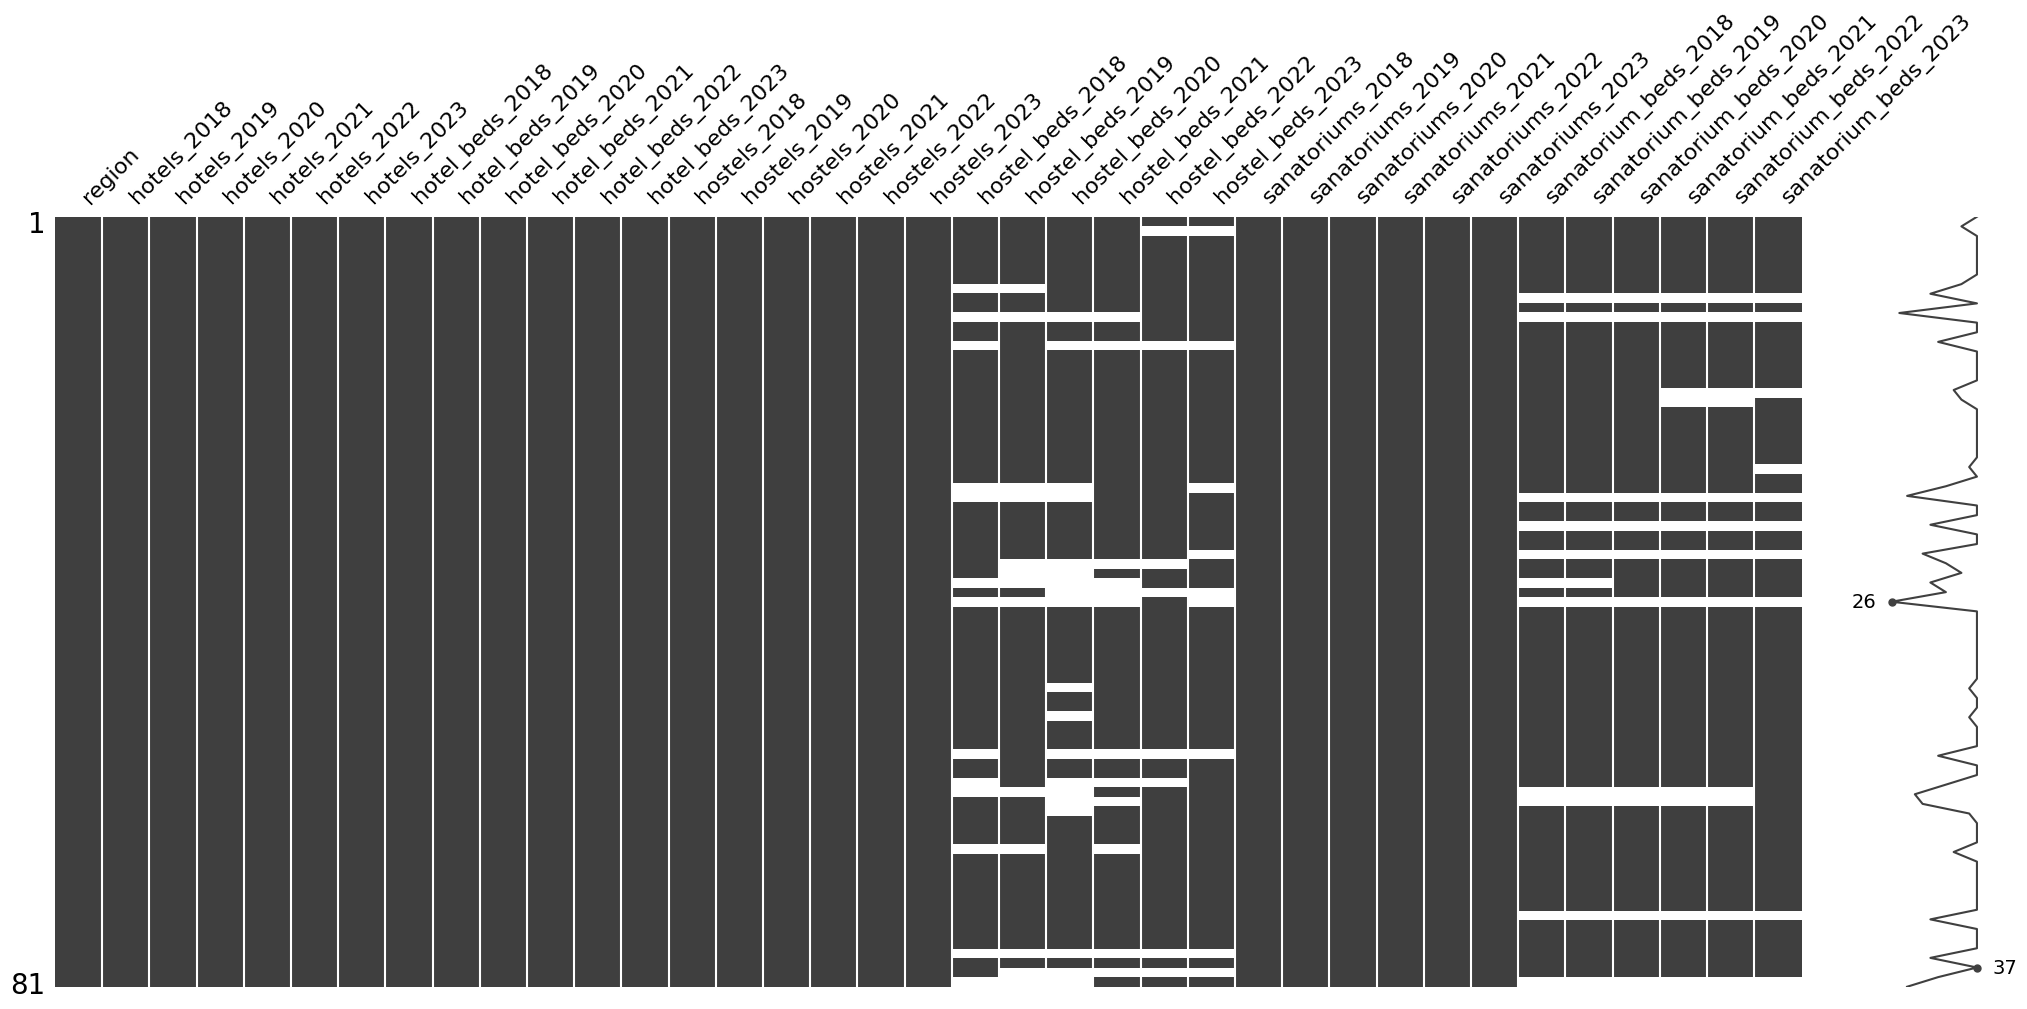

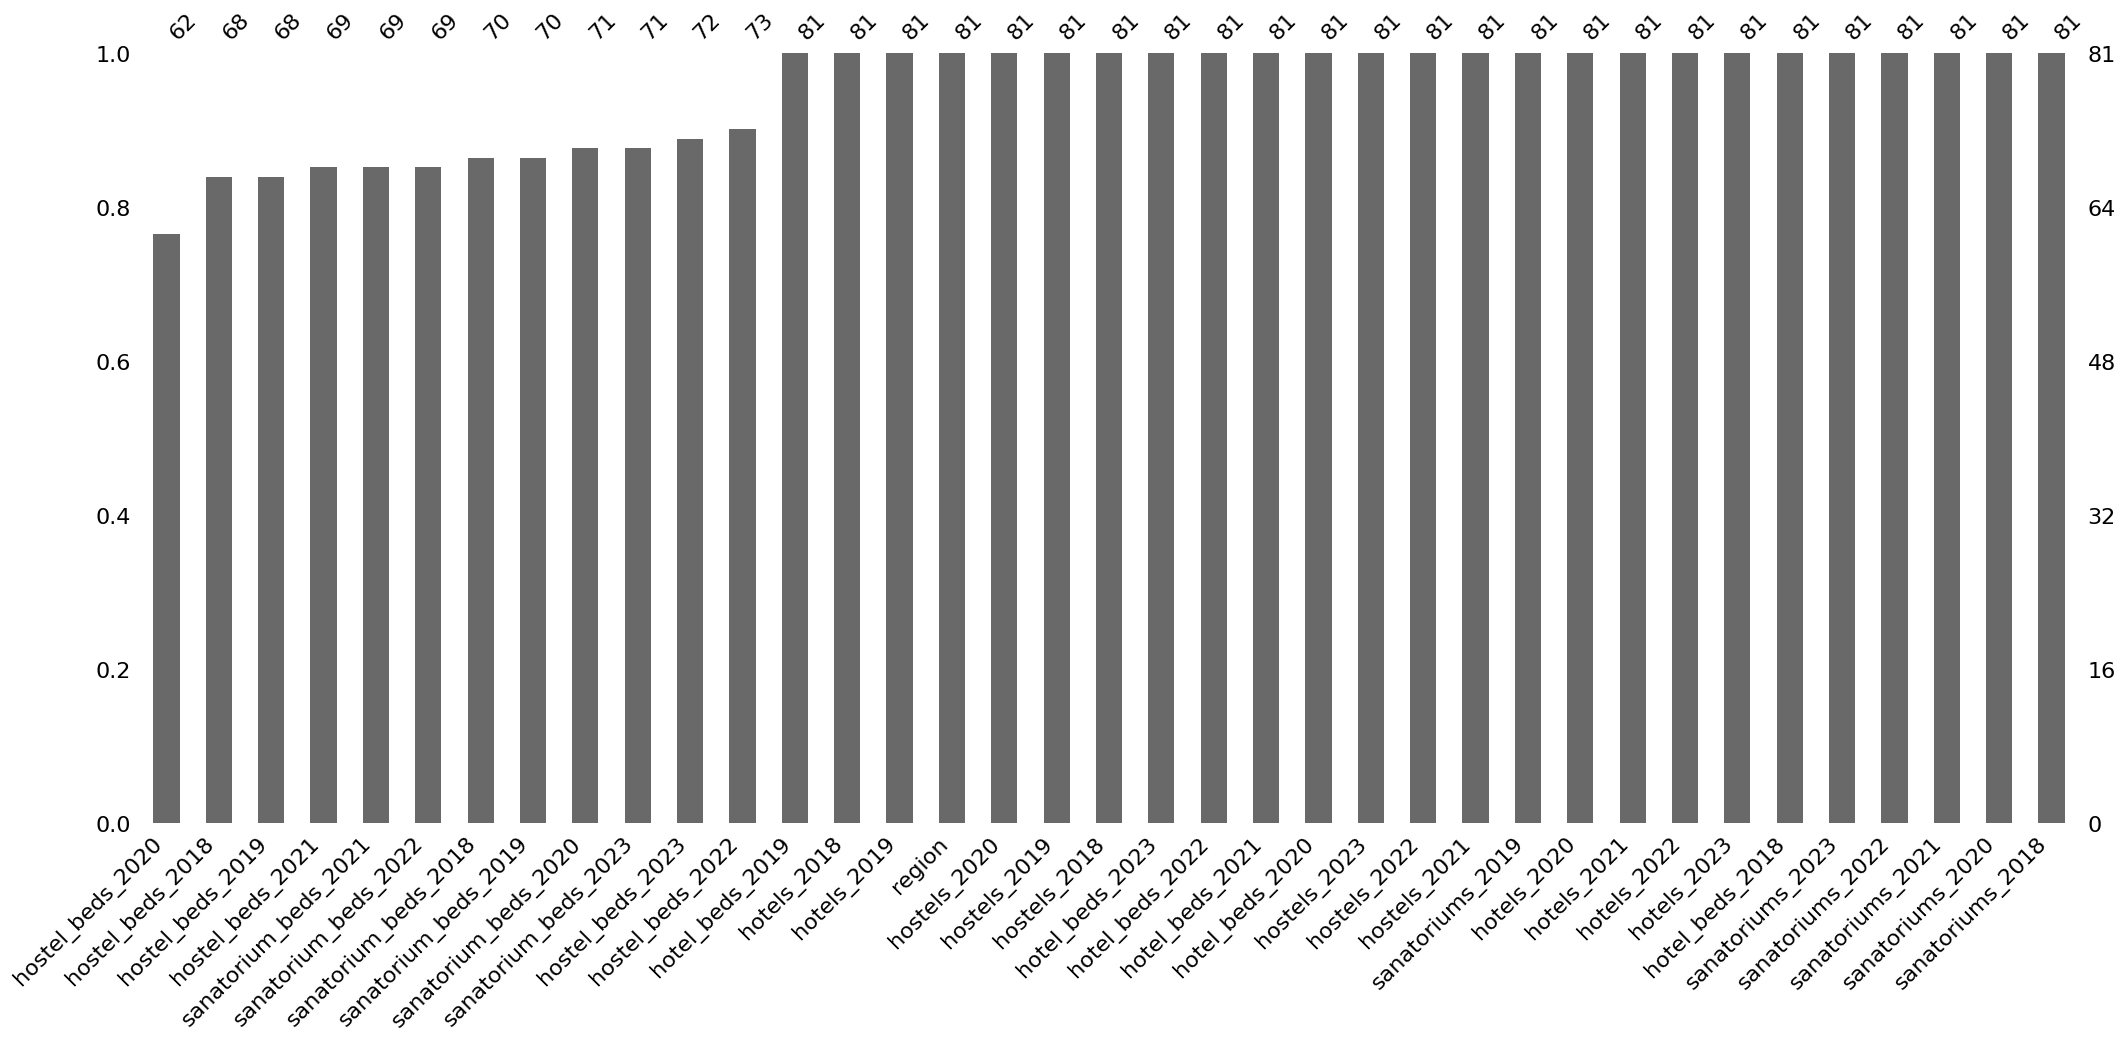

=== count_person ===


<Figure size 1000x400 with 0 Axes>

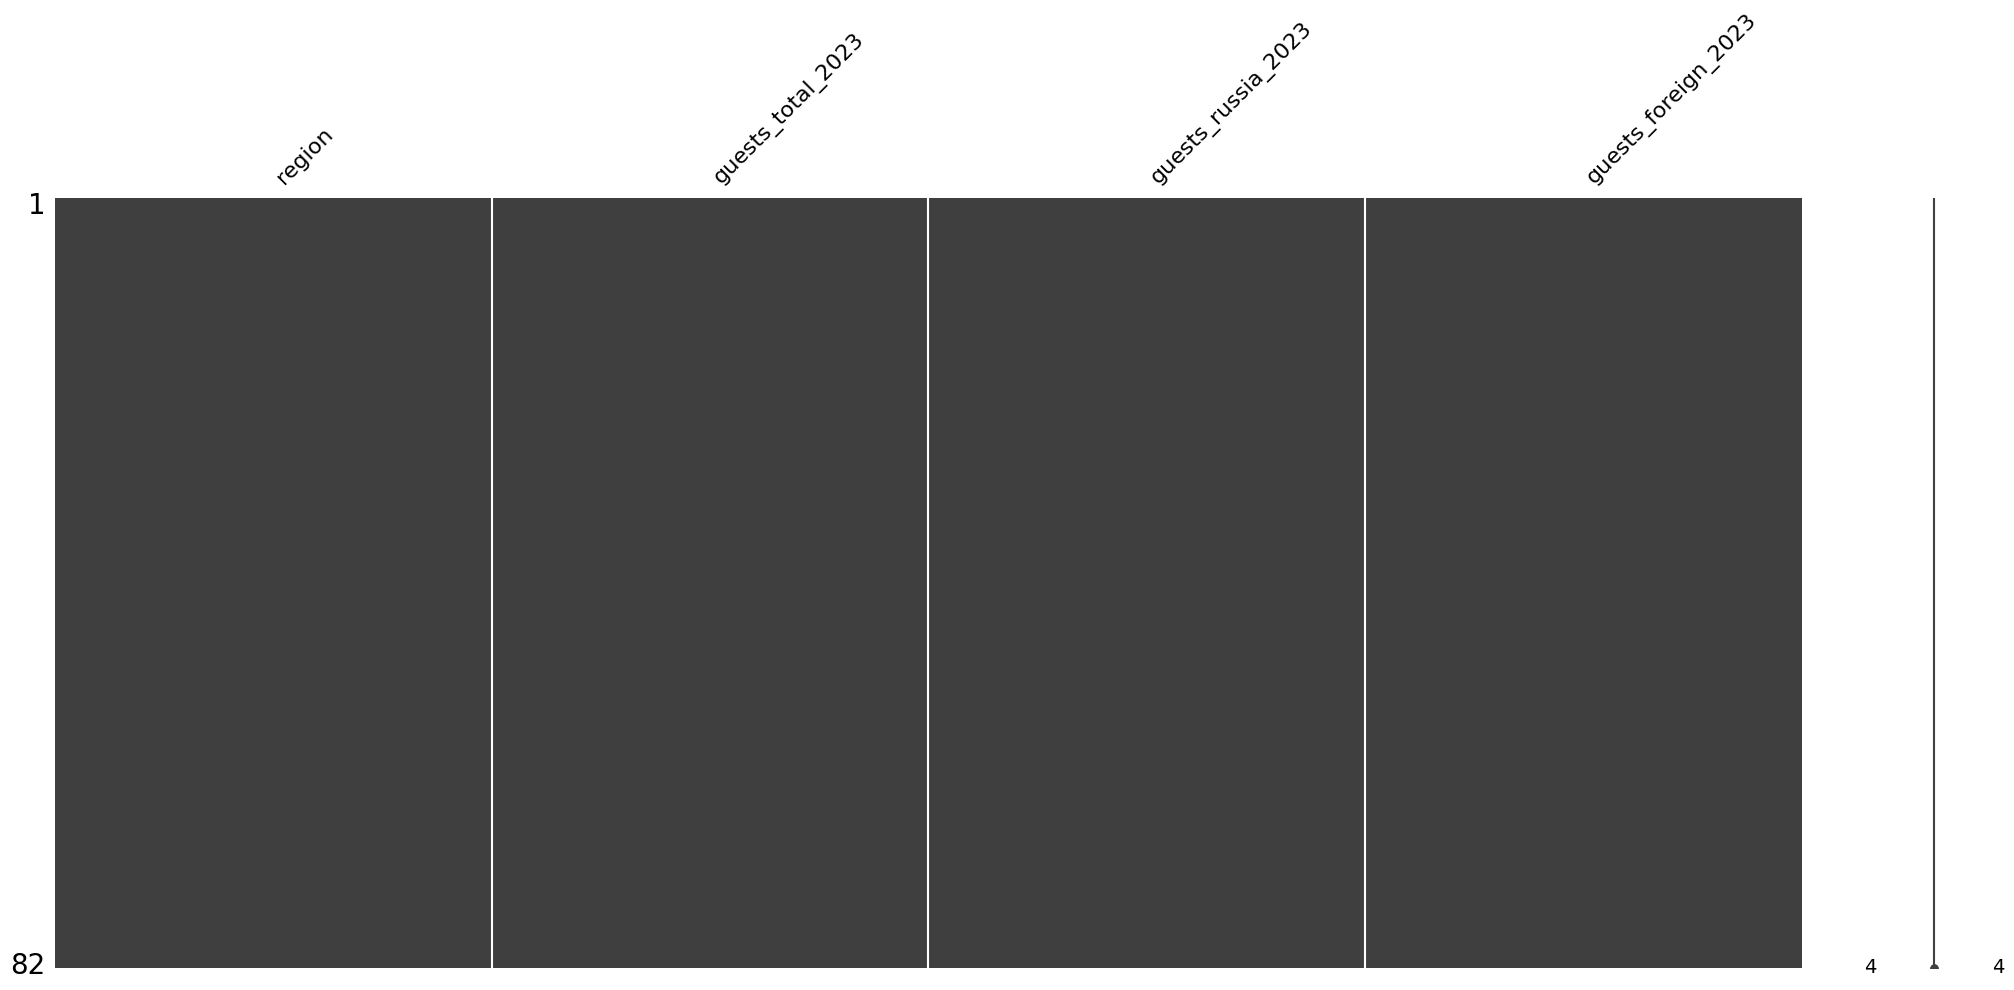

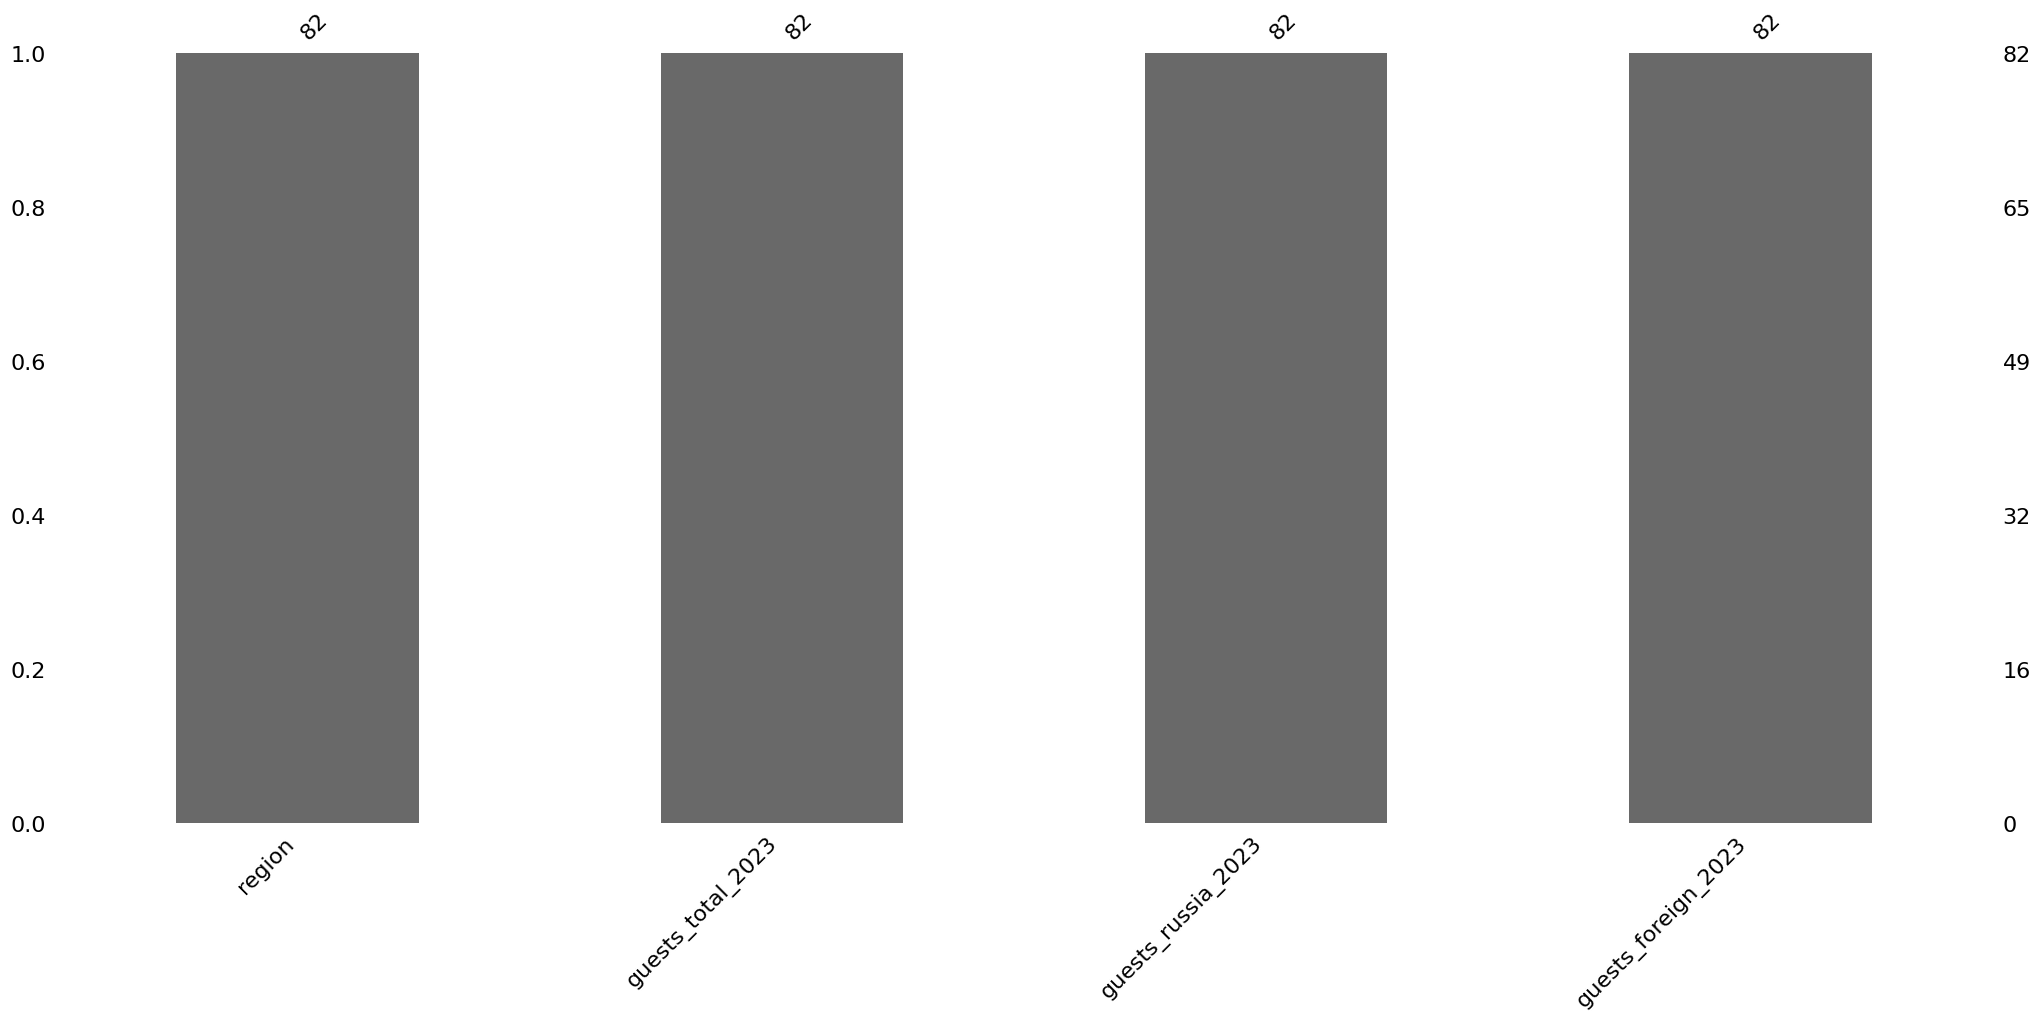

=== tour_firm ===


<Figure size 1000x400 with 0 Axes>

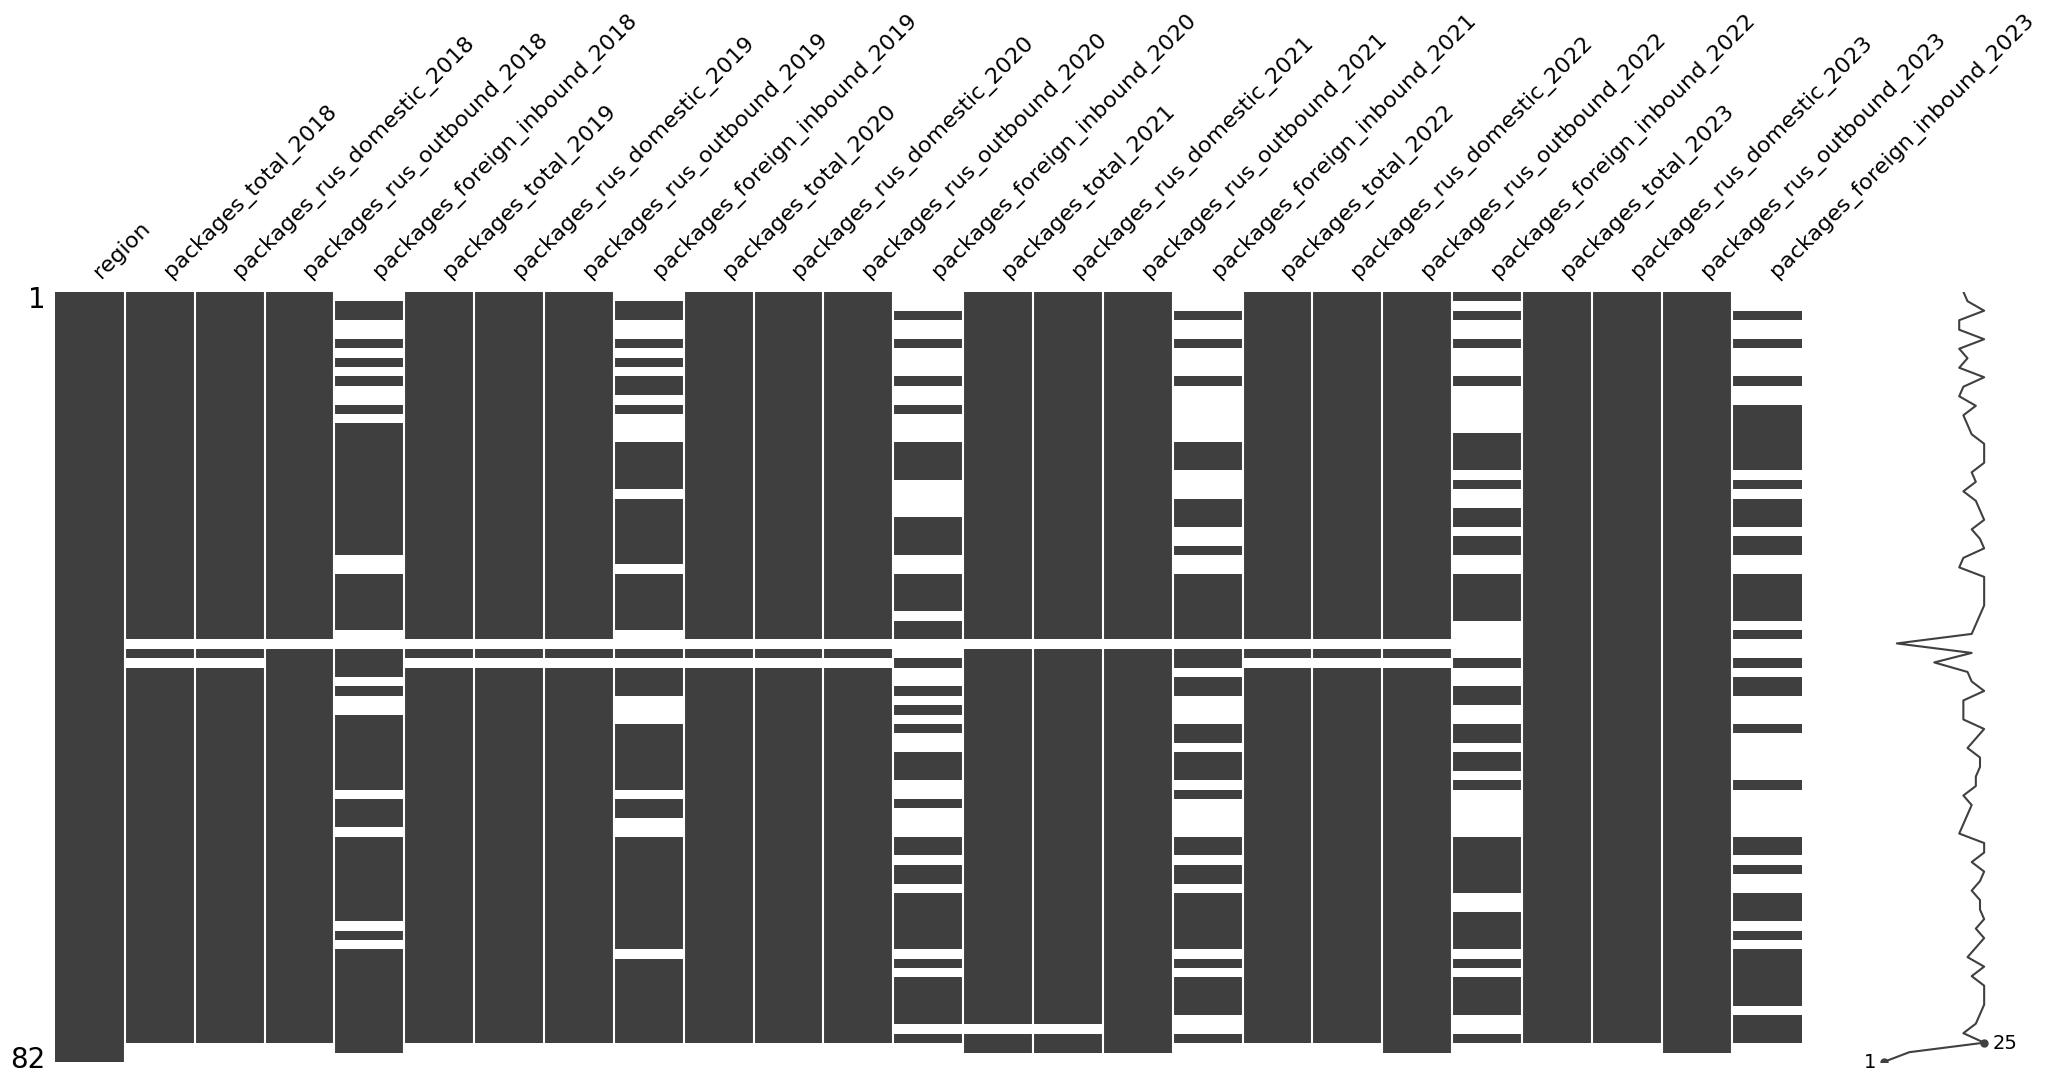

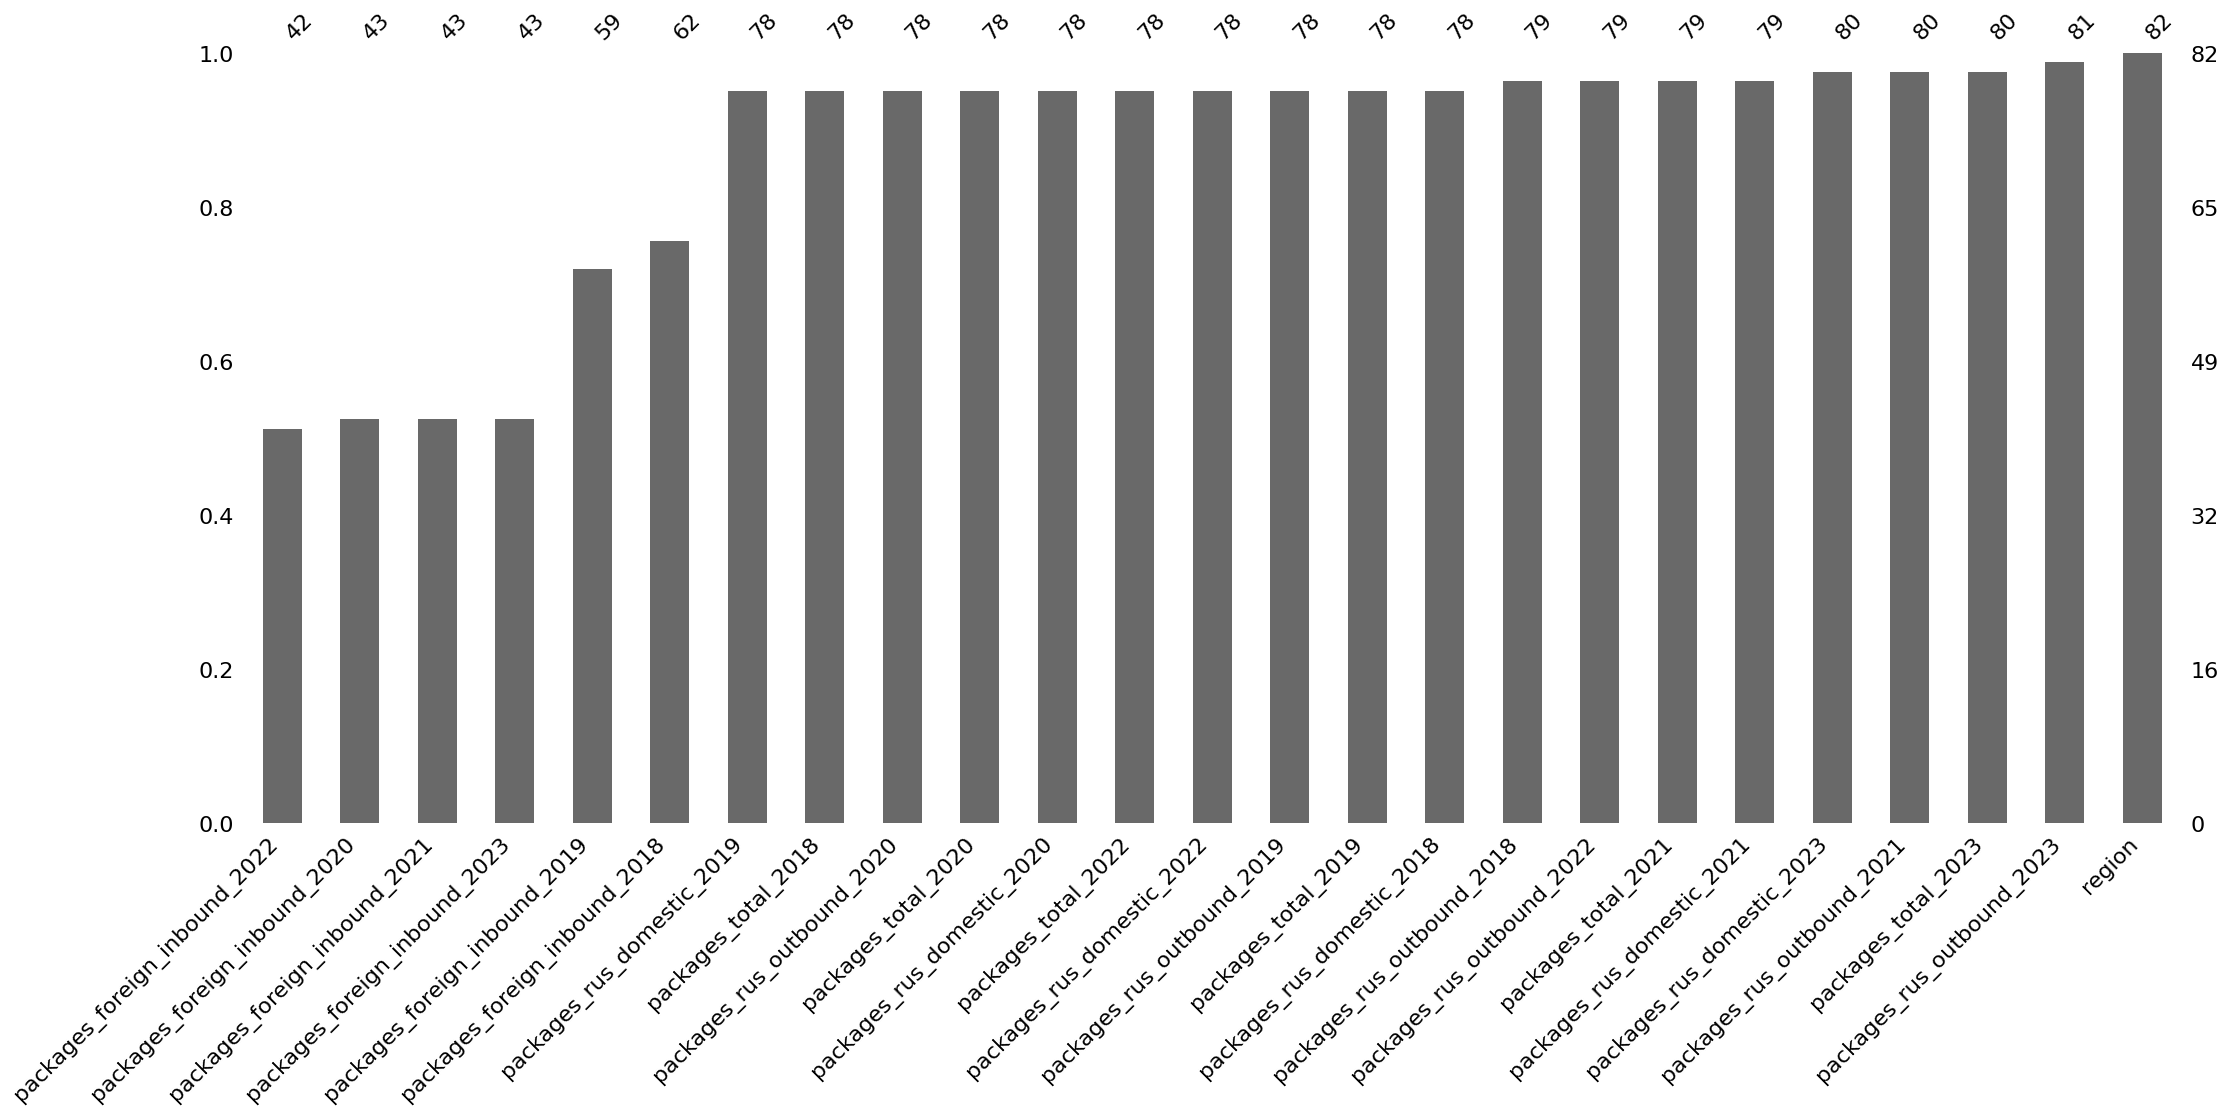

=== tour_cost ===


<Figure size 1000x400 with 0 Axes>

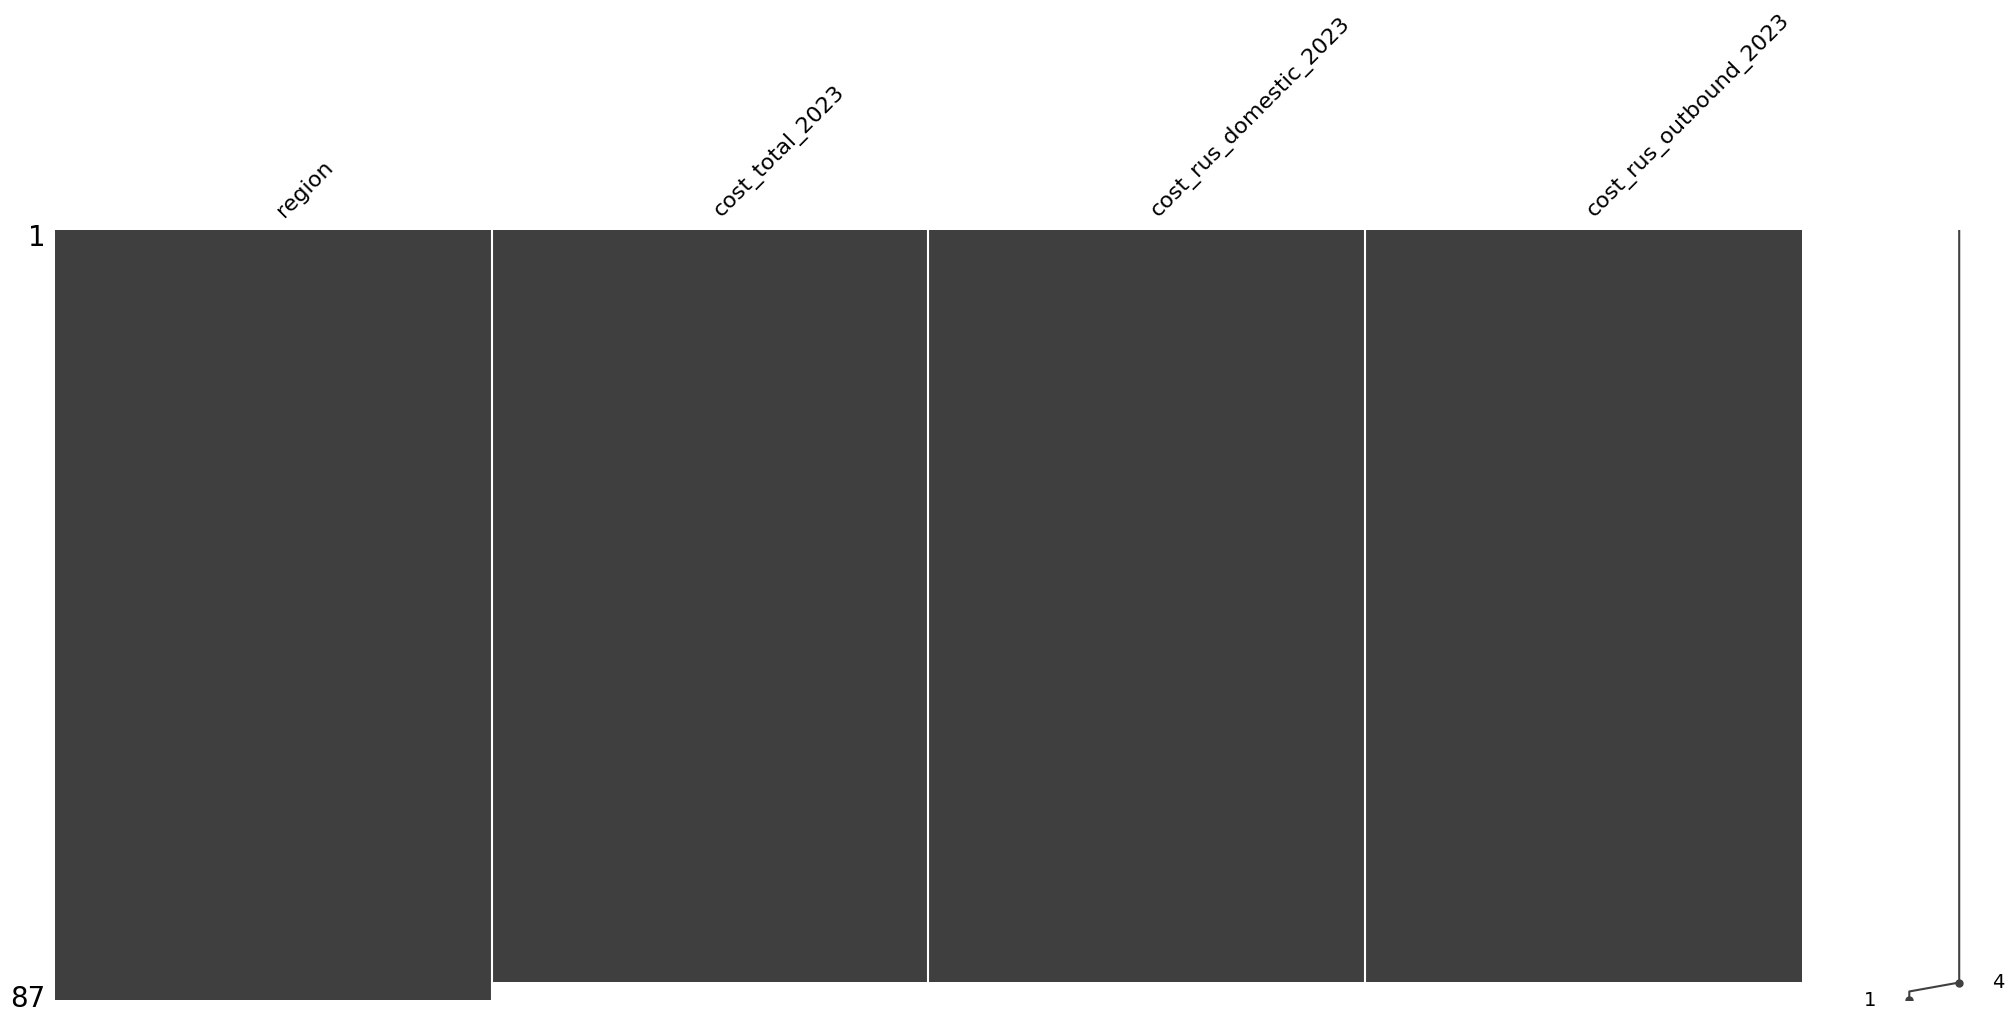

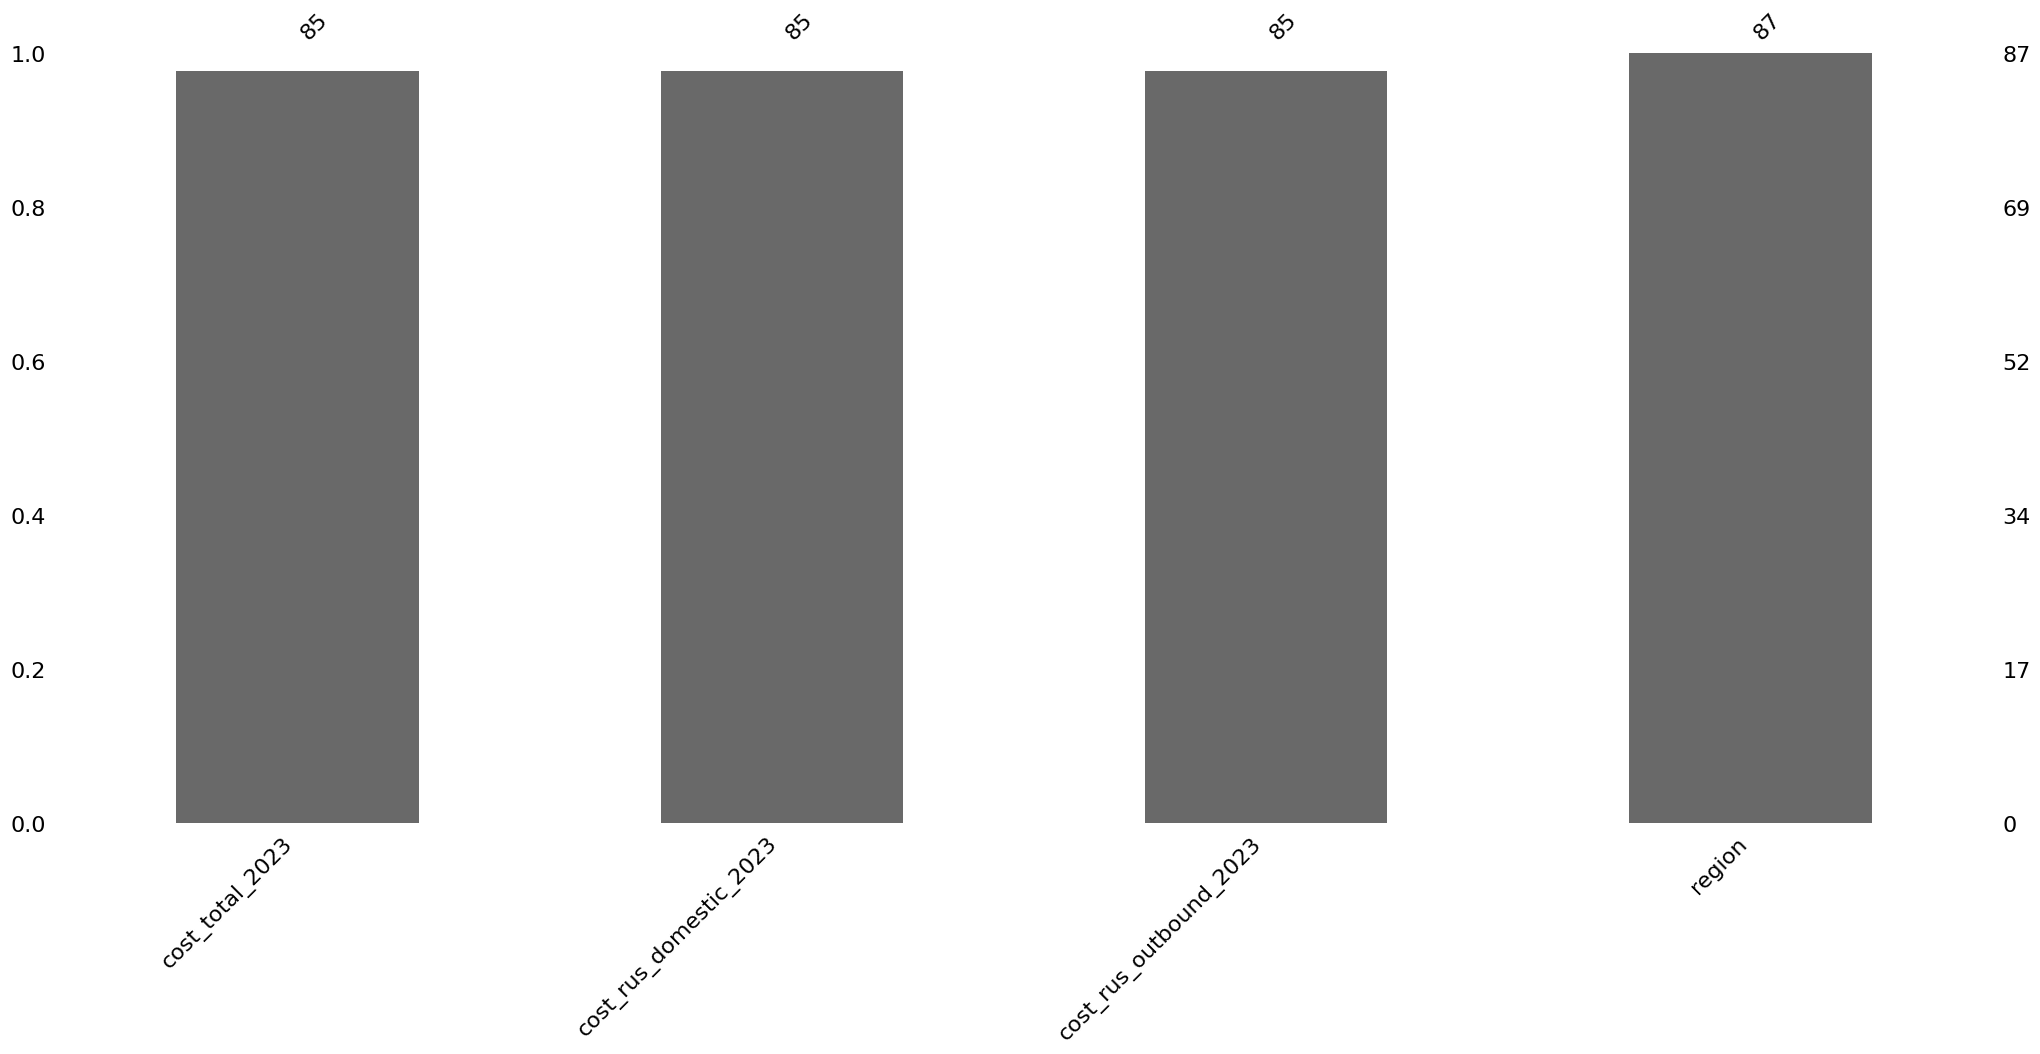

In [ ]:
def plot_missing(df, name: str):
    print(f'=== {name} ===')
    plt.figure(figsize=(10, 4))
    msno.matrix(df)
    plt.show()

    plt.figure(figsize=(10, 4))
    msno.bar(df, sort='ascending')
    plt.show()

plot_missing(hotel, 'hotel')
plot_missing(count_person, 'count_person')
plot_missing(tour_firm, 'tour_firm')
plot_missing(tour_cost, 'tour_cost')

По итогам сводки и визуализаций:

- В `hotel` пропуски есть только в показателях количества мест в хостелах и санаториях, например `hostel_beds_2019`, `hostel_beds_2020`, `sanatorium_beds_2019`, `sanatorium_beds_2020` и т.д. (далее для краткости обозначаем как `hostel_beds_*` и `sanatorium_beds_*`), появившиеся после приведения строк к числовому типу из‑за некорректных исходных записей (пустые ячейки, спецсимволы, текст).
- В `count_person` пропусков нет.
- В `tour_firm` и `tour_cost` пропуски присутствуют в части столбцов: сильнее всего затронуты показатели по иностранному въездному туризму и стоимости турпакетов, что связано с отсутствием деятельности в отдельных регионах или неполной отчётностью.

Предполагаемые причины пропусков:
- отсутствие деятельности (по направлению или виду организации);
- формат исходных файлов (пустые ячейки, дефисы, текст вместо чисел);
- несданная или неполная отчётность по отдельным показателям и годам.

Рекомендации по обработке:
- когда пропуск означает отсутствие деятельности (нет объектов/нет турпакетов) — заменять `NaN` на 0;
- когда пропуск означает отсутствие данных — не заполнять искусственно, а исключать такие регионы/годы из расчётов и фиксировать это в методике;
- в `hotel` при `0` объектов и `NaN` мест заполнять 0, в остальных случаях считать пропуски признаком ошибки данных и осторожно исключать такие строки.

Как снижать количество пропусков в будущем:
- вводить обязательные поля и явное различие между «нет деятельности» и «нет данных»;
- стандартизировать формат выгрузки (только числа в числовых колонках, отдельный флаг для отсутствия данных);
- перед загрузкой в аналитику запускать автоматический отчёт по доле пропусков и запрашивать корректировки у источников.


### 3.4 Проверка числовых значений на аномалии

In [ ]:
# выберем только числовые столбцы
num_cols_hotel = hotel.select_dtypes(include='number')
num_cols_count = count_person.select_dtypes(include='number')
num_cols_firm = tour_firm.select_dtypes(include='number')
num_cols_cost = tour_cost.select_dtypes(include='number')

# базовые описательные статистики
display(num_cols_hotel.describe())
display(num_cols_count.describe())
display(num_cols_firm.describe())
display(num_cols_cost.describe())

# проверка на отрицательные значения
print((num_cols_hotel < 0).sum())
print((num_cols_count < 0).sum())
print((num_cols_firm < 0).sum())
print((num_cols_cost < 0).sum())

,hotels_2018,hotels_2019,hotels_2020,hotels_2021,hotels_2022,hotels_2023,hotel_beds_2018,hotel_beds_2019,hotel_beds_2020,hotel_beds_2021,...,sanatoriums_2020,sanatoriums_2021,sanatoriums_2022,sanatoriums_2023,sanatorium_beds_2018,sanatorium_beds_2019,sanatorium_beds_2020,sanatorium_beds_2021,sanatorium_beds_2022,sanatorium_beds_2023
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,...,81.000000,81.000000,81.000000,81.000000,70.000000,70.000000,71.000000,69.000000,69.000000,71.000000
mean,144.098765,149.160494,149.037037,159.950617,164.148148,178.024691,10966.814815,11261.074074,11274.666667,12096.814815,...,21.617284,21.802469,21.481481,21.456790,6116.214286,6167.342857,6109.887324,6347.884058,6315.014493,6258.098592
std,189.850573,190.102502,186.703873,210.466975,209.092032,242.384249,23272.586894,23384.022458,23256.339677,25308.163929,...,28.607939,28.950570,28.162968,27.851862,13009.311774,13060.648295,13033.652569,13562.292665,13417.574723,13708.638490
min,10.000000,12.000000,12.000000,12.000000,11.000000,11.000000,402.000000,461.000000,512.000000,574.000000,...,1.000000,1.000000,1.000000,1.000000,510.000000,501.000000,512.000000,485.000000,485.000000,383.000000
25%,61.000000,63.000000,65.000000,65.000000,67.000000,72.000000,2930.000000,2998.000000,3040.000000,3352.000000,...,8.000000,8.000000,8.000000,8.000000,1781.500000,1892.750000,1767.000000,1807.000000,1842.000000,1574.000000
50%,87.000000,96.000000,100.000000,103.000000,111.000000,113.000000,4753.000000,5144.000000,4873.000000,5197.000000,...,14.000000,14.000000,13.000000,13.000000,3117.500000,3180.000000,3220.000000,3206.000000,3186.000000,3286.000000
75%,160.000000,175.000000,179.000000,204.000000,195.000000,212.000000,9605.000000,10138.000000,10484.000000,10500.000000,...,23.000000,23.000000,24.000000,24.000000,5605.500000,5715.250000,5751.000000,5829.000000,5476.000000,5573.000000
max,1369.000000,1369.000000,1443.000000,1662.000000,1627.000000,1896.000000,151687.000000,149634.000000,165501.000000,184431.000000,...,192.000000,202.000000,191.000000,189.000000,98378.000000,99231.000000,99538.000000,102948.000000,101771.000000,105681.000000


,guests_total_2023,guests_russia_2023,guests_foreign_2023
count,8.200000e+01,8.200000e+01,8.200000e+01
mean,6.841199e+05,6.526328e+05,3.148709e+04
std,1.375353e+06,1.257496e+06,1.369378e+05
min,7.664000e+03,7.532000e+03,1.320000e+02
25%,1.796448e+05,1.746580e+05,2.752750e+03
50%,3.043885e+05,2.928150e+05,7.463500e+03
75%,6.659235e+05,6.488710e+05,1.545375e+04
max,9.896299e+06,8.704963e+06,1.191336e+06


,packages_total_2018,packages_rus_domestic_2018,packages_rus_outbound_2018,packages_foreign_inbound_2018,packages_total_2019,packages_rus_domestic_2019,packages_rus_outbound_2019,packages_foreign_inbound_2019,packages_total_2020,packages_rus_domestic_2020,...,packages_rus_outbound_2021,packages_foreign_inbound_2021,packages_total_2022,packages_rus_domestic_2022,packages_rus_outbound_2022,packages_foreign_inbound_2022,packages_total_2023,packages_rus_domestic_2023,packages_rus_outbound_2023,packages_foreign_inbound_2023
count,7.800000e+01,78.000000,79.000000,62.000000,7.800000e+01,78.000000,7.800000e+01,59.000000,7.800000e+01,7.800000e+01,...,8.000000e+01,43.000000,7.800000e+01,7.800000e+01,7.900000e+01,42.000000,8.000000e+01,8.000000e+01,8.100000e+01,43.000000
mean,5.874203e+04,20957.307692,32586.139241,6046.661290,6.832876e+04,27014.910256,3.728791e+04,5322.423729,4.004904e+04,2.683359e+04,...,2.428312e+04,285.604651,6.765636e+04,3.886633e+04,2.829497e+04,252.452381,7.960019e+04,4.166622e+04,3.714338e+04,617.255814
std,1.412837e+05,39565.220008,98399.477612,23194.364332,2.116050e+05,77649.179465,1.274634e+05,18816.626345,1.891199e+05,1.252718e+05,...,1.181403e+05,1030.684311,2.757288e+05,1.262600e+05,1.500656e+05,890.417967,3.463070e+05,1.475541e+05,1.981240e+05,2270.801338
min,1.184000e+03,234.000000,418.000000,1.000000,1.071000e+03,263.000000,5.390000e+02,1.000000,1.880000e+02,1.170000e+02,...,8.600000e+01,1.000000,3.380000e+02,1.620000e+02,1.100000e+02,1.000000,3.790000e+02,1.570000e+02,7.900000e+01,1.000000
25%,1.065725e+04,3457.250000,5832.000000,19.250000,1.234600e+04,3314.500000,6.300750e+03,15.000000,3.761000e+03,2.351250e+03,...,2.387500e+03,3.500000,7.683250e+03,4.352500e+03,2.918500e+03,3.000000,9.492750e+03,4.680500e+03,4.080000e+03,2.000000
50%,2.336450e+04,7937.500000,10811.000000,120.500000,2.363200e+04,8339.000000,1.168450e+04,133.000000,9.806500e+03,5.386000e+03,...,6.492000e+03,20.000000,1.885200e+04,1.233500e+04,6.924000e+03,9.000000,2.295800e+04,1.243700e+04,8.647000e+03,20.000000
75%,5.295950e+04,21582.250000,27446.500000,1076.250000,5.011725e+04,23331.250000,2.730750e+04,1161.500000,2.302600e+04,1.798400e+04,...,1.137525e+04,73.000000,4.267575e+04,3.023600e+04,1.164550e+04,50.000000,4.856300e+04,2.989475e+04,1.621900e+04,96.500000
max,1.141105e+06,233394.000000,860686.000000,156099.000000,1.795809e+06,631769.000000,1.114282e+06,116236.000000,1.670985e+06,1.103909e+06,...,1.056771e+06,6417.000000,2.419418e+06,1.077364e+06,1.337117e+06,4937.000000,3.095421e+06,1.293304e+06,1.790081e+06,12036.000000


,cost_total_2023,cost_rus_domestic_2023,cost_rus_outbound_2023
count,85.000000,85.000000,85.000000
mean,8579.186196,1985.398684,6571.790866
std,41961.924483,6763.784607,35177.807840
min,31.232000,10.294000,20.938000
25%,1098.784400,306.374200,673.603900
50%,2599.052900,630.467800,1652.386600
75%,4927.968000,1486.301200,3307.124000
max,388215.547700,61611.108500,325476.700800


hotels_2018             0
hotels_2019             0
hotels_2020             0
hotels_2021             0
hotels_2022             0
hotels_2023             0
hotel_beds_2018         0
hotel_beds_2019         0
hotel_beds_2020         0
hotel_beds_2021         0
hotel_beds_2022         0
hotel_beds_2023         0
hostels_2018            0
hostels_2019            0
hostels_2020            0
hostels_2021            0
hostels_2022            0
hostels_2023            0
hostel_beds_2018        0
hostel_beds_2019        0
hostel_beds_2020        0
hostel_beds_2021        0
hostel_beds_2022        0
hostel_beds_2023        0
sanatoriums_2018        0
sanatoriums_2019        0
sanatoriums_2020        0
sanatoriums_2021        0
sanatoriums_2022        0
sanatoriums_2023        0
sanatorium_beds_2018    0
sanatorium_beds_2019    0
sanatorium_beds_2020    0
sanatorium_beds_2021    0
sanatorium_beds_2022    0
sanatorium_beds_2023    0
dtype: int64
guests_total_2023      0
guests_russia_2023     0
g

In [ ]:
print('hostel_beds_2018 (hotel):')
print(hotel['hostel_beds_2018'].unique()[:30])

print('\npackages_total_2018 (tour_firm):')
print(tour_firm['packages_total_2018'].unique()[:30])

hostel_beds_2018 (hotel):
[  192.     0.   954.  1257.   184.   432.   356.    nan   350.  5822.
   352.   226.   491.   341.   428. 94749.   284.   163.   195.  1398.
  1059.   675.   814.   439.   221.  8833.  1144.  6291.   136.  1494.]

packages_total_2018 (tour_firm):
[  14138.    9444.   23900.   14554.   17049.   39436.    7514.   10008.
    9307.   90769.    9426.   19380.    8597.    4937.   42819.   17012.
   45116. 1141105.   37138.   18465.   40073.   31355.   51653.   22829.
   16721.    9953.   10481.  518939.    4333.    2065.]


- Для всех датасетов рассчитаны описательные статистики по числовым признакам и выполнена проверка на отрицательные значения.

- Отрицательных значений не обнаружено, диапазоны показателей выглядят реалистично для региональных данных.


##4. Исследовательский анализ данных (EDA)

---




###4.1 Распределение средств размещения

Здесь исследуется распределение количества гостиниц, хостелов и санаторно-курортных организаций по регионам и годам, строятся «ящики с усами» и описываются ключевые особенности.


In [ ]:
def plot_box_by_year(df, value_cols, value_name, title):
    """
    Строит boxplot-распределение показателя по годам для всех регионов.
    """
    df_long = df.melt(
        id_vars='region',
        value_vars=value_cols,
        var_name='year',
        value_name=value_name
    )
    df_long['year'] = df_long['year'].str.extract('(\d{4})').astype(int)

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        data=df_long,
        x='year',
        y=value_name,
        boxprops=dict(
            facecolor='none',     # прозрачная заливка
            edgecolor='gray',     # серый контур «ящика»
            linewidth=1.5
        ),
        medianprops=dict(         # зелёная медиана
            color='green',
            linewidth=2
        ),
        whiskerprops=dict(color='gray', linewidth=1.5),
        capprops=dict(color='gray', linewidth=1.5),
        flierprops=dict(markeredgecolor='gray', marker='o', markersize=4)
    )
    ax.grid(False)
    plt.title(title)
    plt.xlabel('Год')
    plt.ylabel(value_name)
    plt.show()


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_12609/2551723198.py:11: SyntaxWarning: invalid escape sequence '\d'
  df_long['year'] = df_long['year'].str.extract('(\d{4})').astype(int)


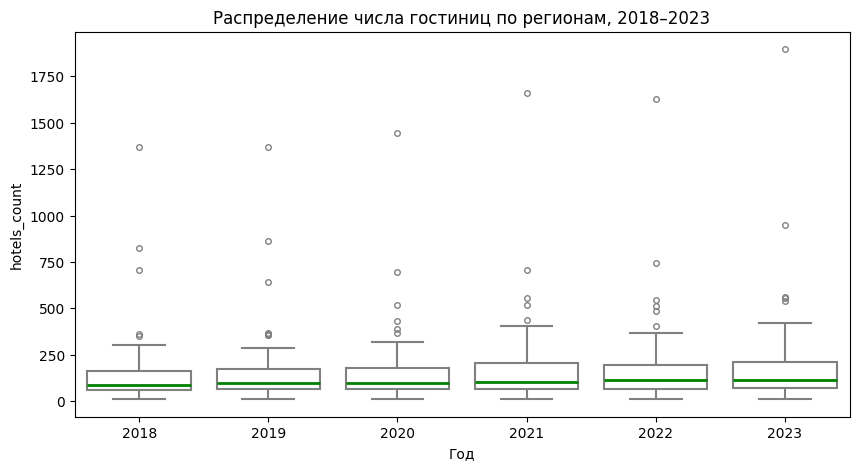

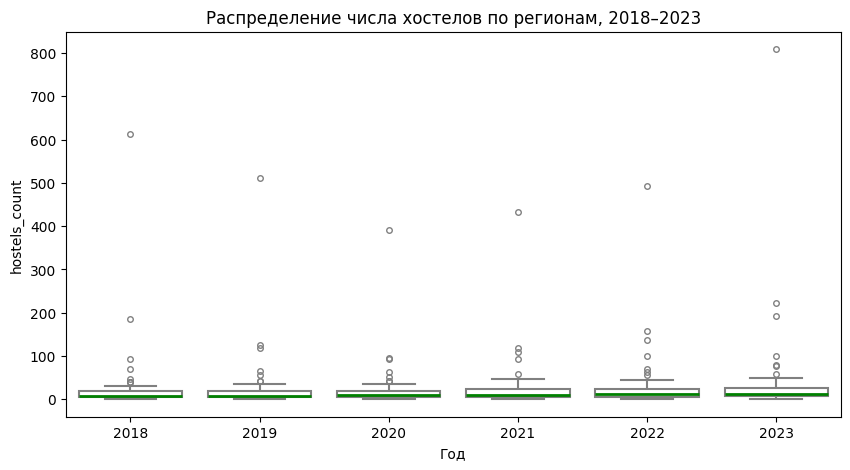

In [ ]:
# Гостиницы
plot_box_by_year(
    hotel,
    [f'hotels_{y}' for y in range(2018, 2024)],
    'hotels_count',
    'Распределение числа гостиниц по регионам, 2018–2023'
)

# Хостелы
plot_box_by_year(
    hotel,
    [f'hostels_{y}' for y in range(2018, 2024)],
    'hostels_count',
    'Распределение числа хостелов по регионам, 2018–2023'
)


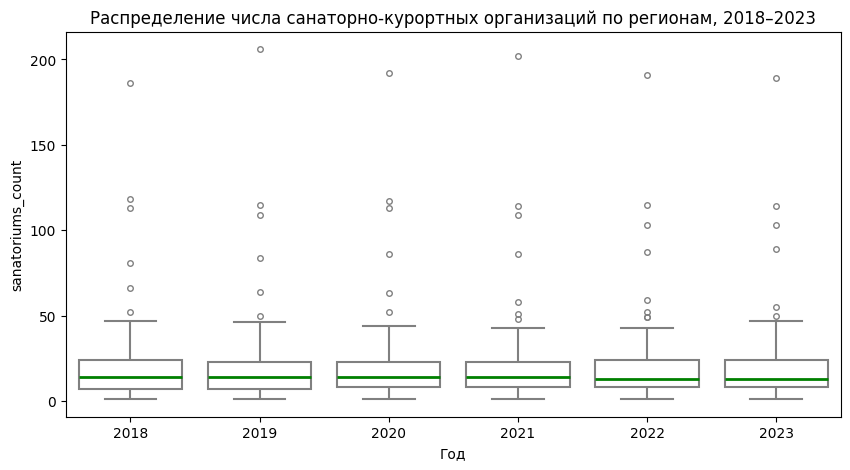

In [ ]:
# Санаторно-курортные организации
plot_box_by_year(
    hotel,
    [f'sanatoriums_{y}' for y in range(2018, 2024)],
    'sanatoriums_count',
    'Распределение числа санаторно-курортных организаций по регионам, 2018–2023'
)

- По boxplot-графикам видно, что медианы числа гостиниц, хостелов и санаторно‑курортных организаций по регионам остаются относительно стабильными, а рост происходит в верхних «усах», что отражает усиление инфраструктуры в отдельных регионах‑лидерах.

- В 2022–2023 годах особенно заметно расширение рынка хостелов в отдельных туристических центрах, а также наличие выбросов по санаториям: у части регионов число санаторно‑курортных организаций превышает 100–200 при типичных значениях ниже 50.


###4.2 Топ-10 регионов по стоимости турпакетов в 2023 году

В этом подразделе определяются регионы‑лидеры по общей стоимости реализованных турпакетов в 2023 году и интерпретируются полученные результаты.


/tmp/ipykernel_12609/685383747.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


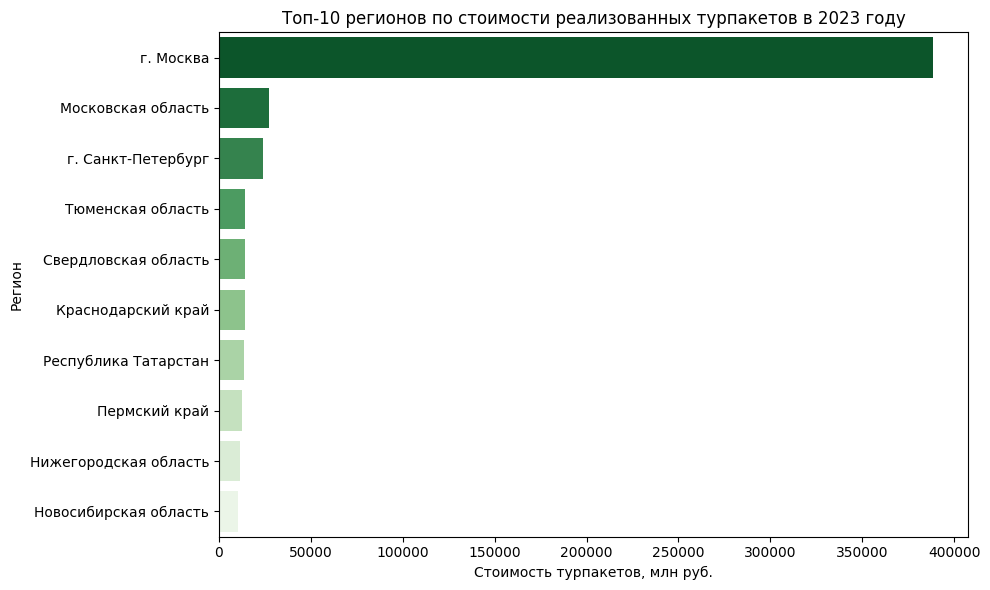

In [ ]:
top10_cost = (
    tour_cost
    .dropna(subset=['cost_total_2023'])
    .sort_values('cost_total_2023', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

# палитра от тёмного к светлому
base_palette = sns.color_palette("Greens", n_colors=len(top10_cost))
palette = base_palette[::-1]

sns.barplot(
    data=top10_cost,
    x='cost_total_2023',
    y='region',
    palette=palette
)

plt.title('Топ‑10 регионов по стоимости реализованных турпакетов в 2023 году')
plt.xlabel('Стоимость турпакетов, млн руб.')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()


- Москва остаётся абсолютным лидером по общей стоимости реализованных турпакетов в 2023 году: объём выручки здесь заметно превышает показатели остальных регионов, что указывает на колоссальную концентрацию платёжеспособного туристического спроса в столице.


###4.3 Динамика среднего количества турпакетов по категориям

Здесь анализируется изменение среднего числа турпакетов по основным категориям с 2018 по 2023 год с помощью линейных графиков.


In [ ]:
average_values = {
    'Year': ['2018', '2019', '2020', '2021', '2022', '2023'],
    'Total Packages': [
        tour_firm['packages_total_2018'].mean(),
        tour_firm['packages_total_2019'].mean(),
        tour_firm['packages_total_2020'].mean(),
        tour_firm['packages_total_2021'].mean(),
        tour_firm['packages_total_2022'].mean(),
        tour_firm['packages_total_2023'].mean(),
    ],
    'Domestic Russia': [
        tour_firm['packages_rus_domestic_2018'].mean(),
        tour_firm['packages_rus_domestic_2019'].mean(),
        tour_firm['packages_rus_domestic_2020'].mean(),
        tour_firm['packages_rus_domestic_2021'].mean(),
        tour_firm['packages_rus_domestic_2022'].mean(),
        tour_firm['packages_rus_domestic_2023'].mean(),
    ],
    'International Russia': [
        tour_firm['packages_rus_outbound_2018'].mean(),
        tour_firm['packages_rus_outbound_2019'].mean(),
        tour_firm['packages_rus_outbound_2020'].mean(),
        tour_firm['packages_rus_outbound_2021'].mean(),
        tour_firm['packages_rus_outbound_2022'].mean(),
        tour_firm['packages_rus_outbound_2023'].mean(),
    ],
    'Foreign in Russia': [
        tour_firm['packages_foreign_inbound_2018'].mean(),
        tour_firm['packages_foreign_inbound_2019'].mean(),
        tour_firm['packages_foreign_inbound_2020'].mean(),
        tour_firm['packages_foreign_inbound_2021'].mean(),
        tour_firm['packages_foreign_inbound_2022'].mean(),
        tour_firm['packages_foreign_inbound_2023'].mean(),
    ]
}


In [ ]:
df_avg = pd.DataFrame(average_values)
df_avg


,Year,Total Packages,Domestic Russia,International Russia,Foreign in Russia
0,2018,58742.025641,20957.307692,32586.139241,6046.661290
1,2019,68328.756410,27014.910256,37287.910256,5322.423729
2,2020,40049.038462,26833.589744,12979.846154,428.209302
3,2021,60887.696203,36150.772152,24283.125000,285.604651
4,2022,67656.358974,38866.333333,28294.974684,252.452381
5,2023,79600.187500,41666.225000,37143.382716,617.255814


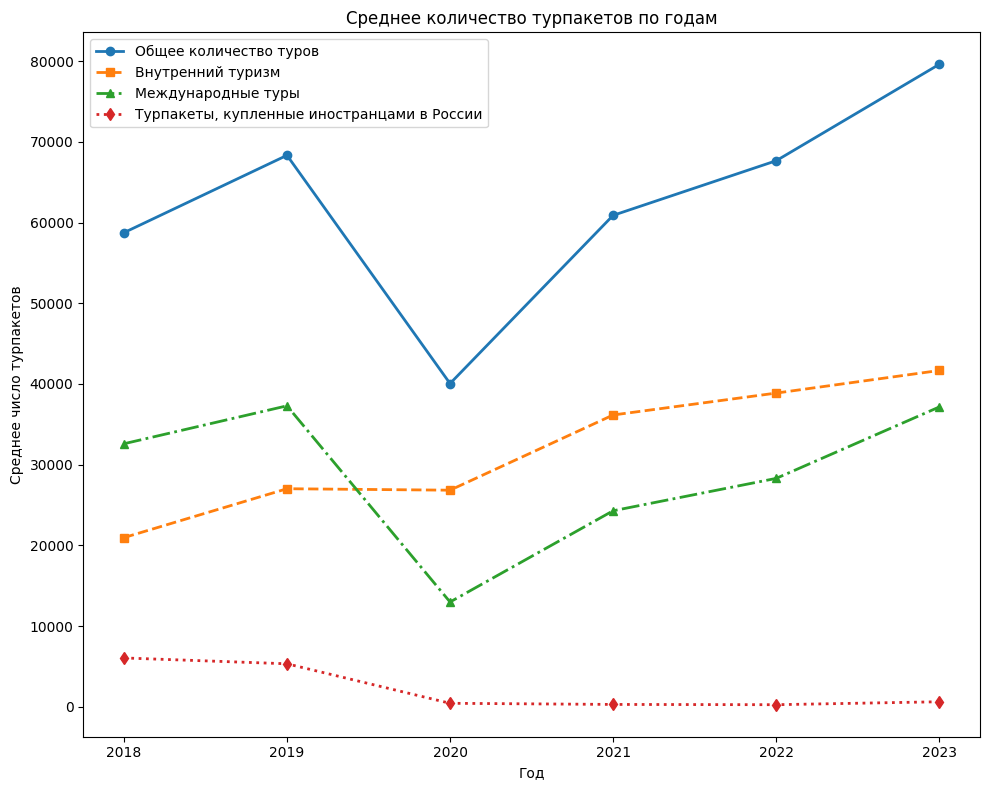

In [ ]:
plt.figure(figsize=(10, 8))

plt.plot(df_avg['Year'], df_avg['Total Packages'],
         marker='o', label='Общее количество туров',
         linestyle='-', linewidth=2)
plt.plot(df_avg['Year'], df_avg['Domestic Russia'],
         marker='s', label='Внутренний туризм',
         linestyle='--', linewidth=2)
plt.plot(df_avg['Year'], df_avg['International Russia'],
         marker='^', label='Международные туры',
         linestyle='-.', linewidth=2)
plt.plot(df_avg['Year'], df_avg['Foreign in Russia'],
         marker='d', label='Турпакеты, купленные иностранцами в России',
         linestyle=':', linewidth=2)

plt.title('Среднее количество турпакетов по годам')
plt.xlabel('Год')
plt.ylabel('Среднее число турпакетов')
plt.legend()
plt.tight_layout()
plt.show()


- Внутренний туризм продолжает расти и достигает пика в 2023 году.
- Международные туры восстановились, но всё ещё немного ниже 2019 года.

##5. Проверка гипотез

---




###5.1 Средняя стоимость турпакетов в 2023 году

В этом подразделе формулируются нулевая и альтернативная гипотезы о средней стоимости турпакетов в 2023 году, выбирается статистический критерий и интерпретируется результат теста.




**Условие.** Некоторые СМИ утверждают, что средняя стоимость реализованных турпакетов в 2023 году составляет 800 млн рублей. Аналитики предполагают, что фактическая средняя стоимость может быть **выше** этого значения. [page:99]

**Нулевая гипотеза (H₀):**  
средняя стоимость реализованных турпакетов в 2023 году равна 800 млн руб.  

**Альтернативная гипотеза (H₁):**  
средняя стоимость реализованных турпакетов в 2023 году больше 800 млн руб.  

Для проверки гипотезы используем одновыборочный t‑критерий Стьюдента по столбцу `cost_total_2023` датафрейма `tour_cost` при уровне значимости α = 0.05.


In [ ]:
import scipy.stats as stats

# Берём значения стоимости турпакетов в 2023 году по регионам
cost_2023 = tour_cost['cost_total_2023'].dropna()

# Гипотетическое среднее по H0 (млн руб.)
mu0 = 800

# Двусторонний t-тест
t_stat, p_two_sided = stats.ttest_1samp(cost_2023, popmean=mu0)

# Односторонний p-value для H1: mean > mu0
if t_stat > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - p_two_sided / 2

t_stat, p_two_sided, p_one_sided


(np.float64(1.7091816894394218),
 np.float64(0.09110956054228028),
 np.float64(0.04555478027114014))

In [ ]:
alpha = 0.05

print(f'Статистика t: {t_stat:.2f}')
print(f'Двусторонний p-value: {p_two_sided:.4f}')
print(f'Односторонний p-value (H1: mean > {mu0}): {p_one_sided:.4f}')

if p_one_sided < alpha:
    print(f'Отвергаем H0: есть статистические основания считать, что средняя '
          f'стоимость турпакетов в 2023 году больше {mu0} млн руб.')
else:
    print(f'Не удалось отвергнуть H0: недостаточно статистических оснований '
          f'утверждать, что средняя стоимость турпакетов в 2023 году больше {mu0} млн руб.')


Статистика t: 1.71
Двусторонний p-value: 0.0911
Односторонний p-value (H1: mean > 800): 0.0456
Отвергаем H0: есть статистические основания считать, что средняя стоимость турпакетов в 2023 году больше 800 млн руб.


- При уровне значимости 5 % односторонний p-value = 0.0456 < 0.05, поэтому мы отвергаем нулевую гипотезу о средней стоимости турпакетов на уровне 800 млн руб. в пользу альтернативной.

- Это означает, что средняя стоимость реализованных турпакетов в 2023 году с высокой вероятностью превышает 800 млн рублей.


###5.2 Изменение внутреннего туризма

Здесь проверяется гипотеза о росте внутреннего туризма в 2023 году по сравнению с 2022 годом на основе данных о турпакетах по территории России.




Статистика говорит, что в 2023 году, по сравнению с 2022, россияне стали чаще ездить по стране и оформлять турпакеты. Проверим статистическую гипотезу о том, стало ли в 2023 году **больше** проданных турпакетов по России, чем в 2022 году.

**Нулевая гипотеза (H₀):**  
среднее количество турпакетов, реализованных гражданам России по территории России в 2022 году, **равно** среднему количеству таких турпакетов в 2023 году.  

**Альтернативная гипотеза (H₁):**  
среднее количество турпакетов, реализованных гражданам России по территории России в 2022 году, **меньше**, чем в 2023 году  
(то есть в 2023 году турпакетов по России стало больше).  

Для проверки используем двухвыборочный t‑критерий Стьюдента с альтернативой `mean_2022 < mean_2023` при уровне значимости α = 0.05.


In [ ]:
domestic_russia_2022 = tour_firm['packages_rus_domestic_2022'].dropna()
domestic_russia_2023 = tour_firm['packages_rus_domestic_2023'].dropna()

alpha = 0.05
domestic_russia_2023.mean()


np.float64(41666.225)

In [ ]:
results = stats.ttest_ind(
    domestic_russia_2022,
    domestic_russia_2023,
    alternative='less'  # H1: mean_2022 < mean_2023
)

print('Статистика t:', results.statistic)
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу: есть статистические основания '
          'считать, что в 2023 году турпакетов по России продаётся больше, чем в 2022 году.')
else:
    print('Не получилось отвергнуть нулевую гипотезу: недостаточно оснований '
          'утверждать, что в 2023 году турпакетов по России стало больше, чем в 2022 году.')


Статистика t: -0.12800884416572536
p-значение: 0.44915342190717794
Не получилось отвергнуть нулевую гипотезу: недостаточно оснований утверждать, что в 2023 году турпакетов по России стало больше, чем в 2022 году.


- Односторонний двухвыборочный t‑тест показал p-value = 0.431 > 0.05, поэтому на уровне значимости 5 % не удалось отвергнуть нулевую гипотезу о равенстве средних значений.
- Это означает, что, хотя среднее количество турпакетов по России в 2023 году (≈ 40650) выше, чем в 2022 году, наблюдаемая разница может быть обусловлена случайными колебаниями, и статистически значимого роста внутреннего туризма по числу турпакетов не зафиксировано.


##6. Выводы

---




###6.1 Общий обзор проделанной работы

- В рамках проекта были проанализированы данные о туристическом рынке России за 2018–2023 годы из четырёх датасетов: средства размещения, поток гостей, турфирмы и стоимость турпакетов.
- Данные были приведены к удобным названиям и типам, проверены на пропуски и аномалии, числовые признаки оптимизированы по памяти.
- Затем выполнен разведочный анализ: описательная статистика, визуализация динамики по годам и топ‑регионов, а также анализ средней стоимости и количества турпакетов по категориям.
- На заключительном этапе проведены статистические тесты по средней стоимости турпакетов в 2023 году и изменению внутреннего туризма между 2022 и 2023 годами.


###6.2 Ключевые выводы

- Предложение средств размещения и номерного фонда в целом растёт, особенно после спада 2020 года.
- Средняя суммарная стоимость турпакетов в 2023 году статистически значимо превышает ориентир в 800 млн руб.  
- Внутренних турпакетов в 2023 году формально больше, чем в 2022‑м, но различия не являются статистически значимыми.
- Въездной и выездной туризм остаются более волатильными сегментами по сравнению с внутренним.
- Сформировалась группа регионов‑лидеров по стоимости турпакетов; у многих регионов показатели заметно ниже среднего.


###6.3 Рекомендации для заказчика

- Усилить присутствие сервиса в регионах‑лидерах по стоимости турпакетов и растущему номерному фонду, фокусируясь на расширении линейки турпакетов и промо‑акциях.
- Развивать внутренний туризм как ключевой сегмент: продвигать пакетные туры по России, в том числе короткие поездки и сезонные предложения.
- В отстающих регионах запускать партнёрские программы с локальными отелями и санаториями, стимулируя формирование доступных пакетных туров.
- В выездном и въездном сегментах применять гибкую маркетинговую стратегию, концентрируясь на направлениях с высокой маржинальностью.  
- Для дальнейшего развития сервиса имеет смысл дополнительно исследовать сезонность спроса, поведение разных сегментов туристов (семьи, молодёжь, бизнес) и связь показателей турпакетов с внешними факторами (доходы населения, транспортная доступность, события).


